## Disclaimer

This assignment was completed with the help of using ChatGPT.
It expects the dataset to be available on Google Drive.

# US Accidents (2016–2023): CPU EDA and Feature Engineering

The notebook contains two complementary analyses:

1. Temporal and environmental patterns.
2. Geographic and road-infrastructure patterns.

The target is Severity (1–4). Engineered features are hypotheses for a future prediction model, not proof of causation.

In [5]:
!pip -q install pyarrow plotly

import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
SEVERITY_ORDER = [1, 2, 3, 4]

## 1. Configure the dataset path

Keep the full CSV in Google Drive. Change only DATA_PATH if your file is stored elsewhere.

In [6]:
from google.colab import drive
drive.mount("/content/drive")

# EDIT THIS PATH if necessary.
BASE_PATH = Path('/content/drive/MyDrive/D230')

DATA_PATH = BASE_PATH / 'US_Accidents_March23.csv'
CLEAN_PATH = BASE_PATH / 'US_Accidents_clean.parquet'

CHUNK_SIZE = 100_000

# Keep False for the full-dataset analysis.
USE_SAMPLE = False
SAMPLE_N = 500_000

if not DATA_PATH.exists():
    raise FileNotFoundError(f"File not found: {DATA_PATH}")
print(f"Dataset: {DATA_PATH}")
print(f"Size: {DATA_PATH.stat().st_size / 1024**3:.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/drive/MyDrive/D230/US_Accidents_March23.csv
Size: 2.85 GB


In [7]:
header = pd.read_csv(DATA_PATH, nrows=5)
print(f"Number of columns: {len(header.columns)}")
display(pd.DataFrame({"column": header.columns, "dtype_preview": header.dtypes.astype(str)}))

Number of columns: 46


,column,dtype_preview
ID,ID,object
Source,Source,object
Severity,Severity,int64
Start_Time,Start_Time,object
End_Time,End_Time,object
Start_Lat,Start_Lat,float64
Start_Lng,Start_Lng,float64
End_Lat,End_Lat,float64
End_Lng,End_Lng,float64
Distance(mi),Distance(mi),float64


## 2. Helper functions

Only the columns needed for each analysis are read. This reduces RAM usage on Colab CPU.

In [8]:
BOOL_COLUMNS = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
    "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop"
]
TRAFFIC_COLUMNS = BOOL_COLUMNS.copy()
BASE_USECOLS = [
    "ID", "Severity", "Start_Time", "State", "City",
    "Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)",
    "Weather_Condition"
]
ALL_ANALYSIS_COLS = list(dict.fromkeys(BASE_USECOLS + TRAFFIC_COLUMNS))

def read_chunks(usecols):
    return pd.read_csv(DATA_PATH, usecols=usecols, chunksize=CHUNK_SIZE,
                       low_memory=True, parse_dates=["Start_Time"],
                       on_bad_lines="warn")

def bool_to_int(series):
    return series.fillna(False).astype(bool).astype("int8")

def classify_weather(value):
    if pd.isna(value): return "Unknown"
    value = str(value).lower()
    if any(x in value for x in ["thunder", "storm"]): return "Storm"
    if any(x in value for x in ["snow", "sleet", "ice", "freezing"]): return "Snow/Ice"
    if any(x in value for x in ["rain", "drizzle", "shower"]): return "Rain"
    if any(x in value for x in ["fog", "haze", "smoke"]): return "Low Visibility"
    if "clear" in value: return "Clear"
    if "cloud" in value or "overcast" in value: return "Cloudy"
    return "Other"

def severity_table(frame, group_col):
    result = frame.groupby(group_col, dropna=False).agg(
        Accident_Count=("Severity", "size"),
        Average_Severity=("Severity", "mean"),
        Severe_Rate=("Is_Severe", "mean")
    ).reset_index()
    result["Severe_Rate"] *= 100
    result["Share_of_Accidents"] = result["Accident_Count"] / result["Accident_Count"].sum() * 100
    return result.sort_values("Accident_Count", ascending=False)

## 3. Basic data audit and cleaning summary

This pass calculates row counts, Severity distribution, missing rates, and the date range without loading the full CSV.

In [9]:
audit = {"rows": 0, "severity": {s: 0 for s in SEVERITY_ORDER},
         "missing": {c: 0 for c in ALL_ANALYSIS_COLS},
         "min_start": None, "max_start": None}

for chunk in read_chunks(ALL_ANALYSIS_COLS):
    if USE_SAMPLE and audit["rows"] >= SAMPLE_N: break
    if USE_SAMPLE:
        chunk = chunk.iloc[:SAMPLE_N - audit["rows"]].copy()
    audit["rows"] += len(chunk)
    for s, count in chunk["Severity"].value_counts(dropna=False).items():
        if s in audit["severity"]: audit["severity"][s] += int(count)
    for c in ALL_ANALYSIS_COLS:
        audit["missing"][c] += int(chunk[c].isna().sum())
    # Normalize every chunk before comparing dates. Mixed CSV parsing can
    # otherwise leave some chunks as strings and others as Timestamps.
    chunk["Start_Time"] = pd.to_datetime(chunk["Start_Time"], errors="coerce")
    low, high = chunk["Start_Time"].min(), chunk["Start_Time"].max()
    if pd.notna(low):
        audit["min_start"] = low if audit["min_start"] is None else min(audit["min_start"], low)
    if pd.notna(high):
        audit["max_start"] = high if audit["max_start"] is None else max(audit["max_start"], high)

n_rows = audit["rows"]
severity_counts = pd.Series(audit["severity"], name="Count")
severity_summary = severity_counts.to_frame()
severity_summary["Percentage"] = severity_summary["Count"] / n_rows * 100
missing_summary = pd.DataFrame({"Missing_Count": audit["missing"]})
missing_summary["Missing_Percentage"] = missing_summary["Missing_Count"] / n_rows * 100

print(f"Rows analyzed: {n_rows:,}")
print(f"Start_Time range: {audit['min_start']} to {audit['max_start']}")
display(severity_summary)
display(missing_summary.sort_values("Missing_Percentage", ascending=False))

Rows analyzed: 7,728,394
Start_Time range: 2016-01-14 20:18:33 to 2023-03-31 23:30:00


,Count,Percentage
1,67366,0.872
2,6156981,79.667
3,1299337,16.813
4,204710,2.649


,Missing_Count,Missing_Percentage
Precipitation(in),2203586,28.513
Wind_Chill(F),1999019,25.866
Wind_Speed(mph),571233,7.391
Visibility(mi),177098,2.292
Humidity(%),174144,2.253
Weather_Condition,173459,2.244
Temperature(F),163853,2.120
Pressure(in),140679,1.820
City,253,0.003
Severity,0,0.000


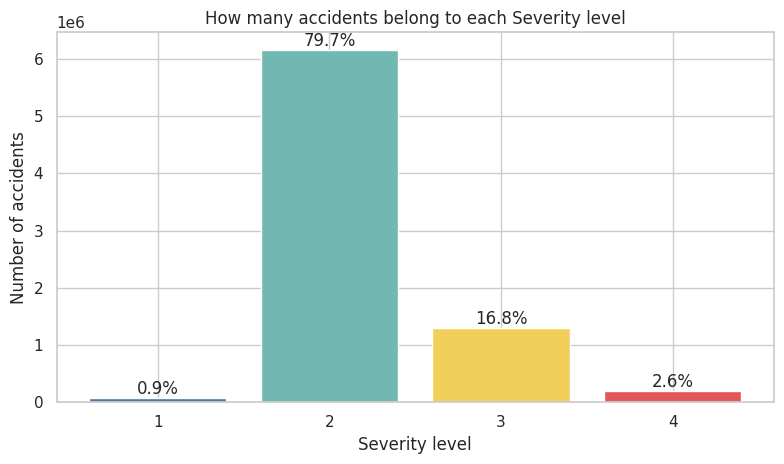

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(severity_counts.index.astype(str), severity_counts.values, color=["#4c78a8", "#72b7b2", "#f2cf5b", "#e45756"])
ax.set_title("How many accidents belong to each Severity level")
ax.set_xlabel("Severity level")
ax.set_ylabel("Number of accidents")
for bar, value in zip(bars, severity_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{value/n_rows*100:.1f}%", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 4. Feature engineering

The engineered features have explicit hypotheses about Severity. The notebook creates time features, weather-event flags, traffic-feature counts, a 0–1 data-quality score, and a month-specific temperature anomaly. No is_weekend feature is used; Day_of_Week is retained instead.

In [11]:
def add_engineered_features(df, month_means=None):
    df = df.copy()
    df["Severity"] = pd.to_numeric(df["Severity"], errors="coerce")
    df = df[df["Severity"].isin(SEVERITY_ORDER)].copy()
    dt = pd.to_datetime(df["Start_Time"], errors="coerce")
    df["Year"], df["Month"] = dt.dt.year, dt.dt.month
    df["Day_of_Week"], df["Hour"], df["Day_of_Year"] = dt.dt.dayofweek, dt.dt.hour, dt.dt.dayofyear
    df["Season"] = df["Month"].map({12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",6:"Summer",7:"Summer",8:"Summer",9:"Autumn",10:"Autumn",11:"Autumn"})
    df["Is_Night"] = ((df["Hour"] < 6) | (df["Hour"] >= 20)).astype("int8")
    df["Is_Rush_Hour"] = df["Hour"].isin([7,8,9,16,17,18]).astype("int8")
    df["Is_Severe"] = (df["Severity"] >= 3).astype("int8")
    df["Weather_Group"] = df["Weather_Condition"].map(classify_weather)
    df["Is_Rain_Day"] = df["Weather_Group"].eq("Rain").astype("int8")
    df["Is_Snow_or_Ice"] = df["Weather_Group"].eq("Snow/Ice").astype("int8")
    df["Is_Low_Visibility_Weather"] = df["Weather_Group"].eq("Low Visibility").astype("int8")
    df["Is_Storm"] = df["Weather_Group"].eq("Storm").astype("int8")
    df["Poor_Visibility"] = (pd.to_numeric(df["Visibility(mi)"], errors="coerce") < 2).astype("int8")
    df["Extreme_Cold"] = (pd.to_numeric(df["Temperature(F)"], errors="coerce") < 32).astype("int8")
    df["Extreme_Hot"] = (pd.to_numeric(df["Temperature(F)"], errors="coerce") > 95).astype("int8")
    df["High_Wind"] = (pd.to_numeric(df["Wind_Speed(mph)"], errors="coerce") > 25).astype("int8")
    for c in TRAFFIC_COLUMNS: df[c] = bool_to_int(df[c])
    df["Traffic_Feature_Count"] = df[TRAFFIC_COLUMNS].sum(axis=1)
    df["No_Traffic_Control"] = (df["Traffic_Feature_Count"] == 0).astype("int8")
    quality_cols = ["Temperature(F)", "Humidity(%)", "Visibility(mi)", "Wind_Speed(mph)", "Weather_Condition"]
    df["Data_Quality_Score"] = 1 - df[quality_cols].isna().mean(axis=1)
    if month_means is not None:
        temp = pd.to_numeric(df["Temperature(F)"], errors="coerce")
        df["Month_Temperature_Anomaly"] = temp - df["Month"].map(month_means)
    return df

In [12]:
# First pass: calculate month-specific means for the temperature anomaly feature.
month_sum = pd.Series(0.0, index=range(1, 13))
month_count = pd.Series(0, index=range(1, 13), dtype="int64")
rows_seen = 0
for chunk in read_chunks(["Start_Time", "Temperature(F)"]):
    if USE_SAMPLE and rows_seen >= SAMPLE_N: break
    if USE_SAMPLE: chunk = chunk.iloc[:SAMPLE_N - rows_seen].copy()
    rows_seen += len(chunk)
    chunk["Start_Time"] = pd.to_datetime(chunk["Start_Time"], errors="coerce")
    chunk["Month"] = chunk["Start_Time"].dt.month
    chunk["Temperature(F)"] = pd.to_numeric(chunk["Temperature(F)"], errors="coerce")
    grouped = chunk.dropna(subset=["Month","Temperature(F)"]).groupby("Month")["Temperature(F)"].agg(["sum","count"])
    month_sum = month_sum.add(grouped["sum"], fill_value=0)
    month_count = month_count.add(grouped["count"], fill_value=0)
month_means = (month_sum / month_count.replace(0, np.nan)).to_dict()
display(pd.DataFrame({"Month": list(month_means), "Mean_Temperature_F": list(month_means.values())}))

,Month,Mean_Temperature_F
0,1.000,44.930
1,2.000,46.724
2,3.000,54.196
3,4.000,61.442
4,5.000,69.633
5,6.000,76.473
6,7.000,79.950
7,8.000,78.932
8,9.000,74.075
9,10.000,64.867


## 5. Analysis A — temporal and environmental patterns

In [13]:
time_parts, weather_parts, numeric_parts = [], [], []

rows_seen = 0

# add_engineered_features() requires the traffic-feature columns
ANALYSIS_USECOLS = list(dict.fromkeys(BASE_USECOLS + TRAFFIC_COLUMNS))

for chunk in read_chunks(ANALYSIS_USECOLS):
    if USE_SAMPLE and rows_seen >= SAMPLE_N:
        break

    if USE_SAMPLE:
        chunk = chunk.iloc[:SAMPLE_N - rows_seen].copy()

    rows_seen += len(chunk)

    eng = add_engineered_features(chunk, month_means)

    time_parts.append(
        eng[
            [
                "Severity",
                "Is_Severe",
                "Year",
                "Month",
                "Day_of_Week",
                "Hour",
                "Season",
                "Is_Night",
                "Is_Rush_Hour",
            ]
        ]
    )

    weather_parts.append(
        eng[
            [
                "Severity",
                "Is_Severe",
                "Weather_Group",
                "Is_Rain_Day",
                "Is_Snow_or_Ice",
                "Is_Low_Visibility_Weather",
                "Is_Storm",
                "Poor_Visibility",
                "Extreme_Cold",
                "Extreme_Hot",
                "High_Wind",
                "Data_Quality_Score",
                "Month_Temperature_Anomaly",
            ]
        ]
    )

    numeric_parts.append(
        eng[
            [
                "Severity",
                "Temperature(F)",
                "Humidity(%)",
                "Visibility(mi)",
                "Wind_Speed(mph)",
                "Month_Temperature_Anomaly",
            ]
        ]
    )

time_df = pd.concat(time_parts, ignore_index=True)
weather_df = pd.concat(weather_parts, ignore_index=True)
numeric_df = pd.concat(numeric_parts, ignore_index=True)

print(f"Engineered rows retained for EDA: {len(time_df):,}")

Engineered rows retained for EDA: 7,728,394


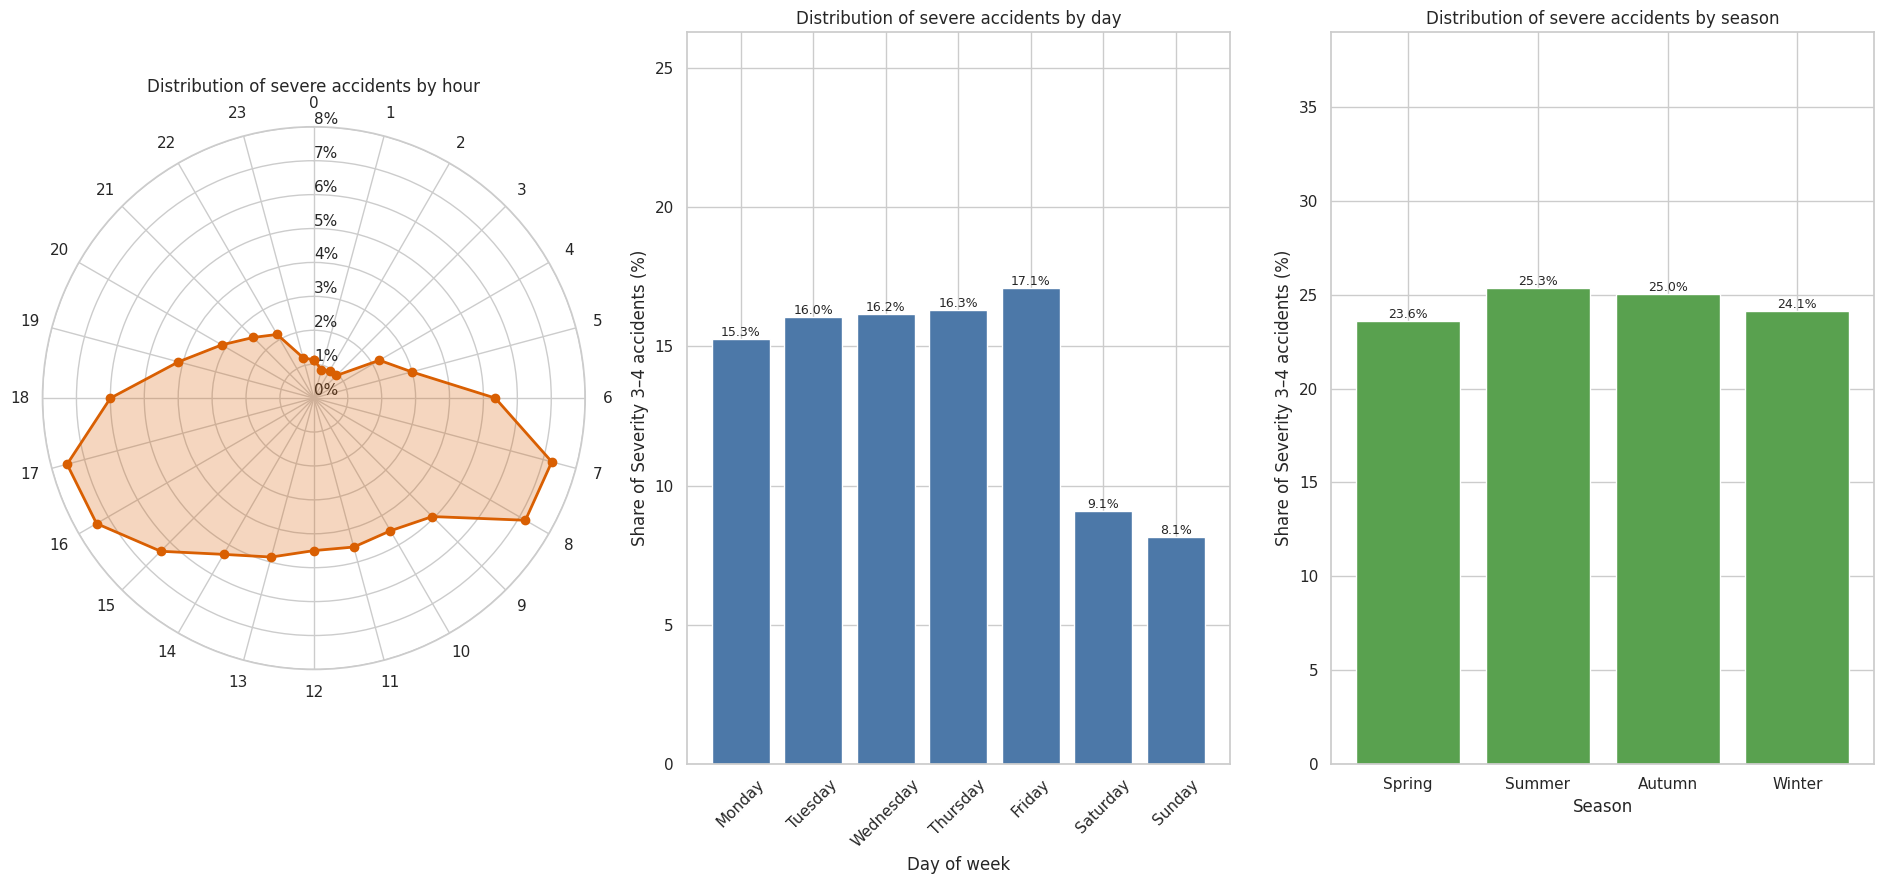

In [14]:
# Keep only severe accidents: Severity 3 and 4
severe_df = time_df[time_df["Is_Severe"] == 1].copy()

total_severe = len(severe_df)

# Severe accidents by hour
hour_summary = (
    severe_df.groupby("Hour")
    .size()
    .reset_index(name="Severe_Accident_Count")
)

hour_summary["Share_of_Severe_Accidents"] = (
    hour_summary["Severe_Accident_Count"] / total_severe * 100
)

hour_summary = hour_summary.sort_values("Hour")
hour_summary["Hour"] = hour_summary["Hour"].astype(int)

# Severe accidents by day
day_summary = (
    severe_df.groupby("Day_of_Week")
    .size()
    .reset_index(name="Severe_Accident_Count")
)

day_summary["Share_of_Severe_Accidents"] = (
    day_summary["Severe_Accident_Count"] / total_severe * 100
)

day_summary = day_summary.sort_values("Day_of_Week")

# Severe accidents by season
season_order = ["Spring", "Summer", "Autumn", "Winter"]

season_summary = (
    severe_df.groupby("Season")
    .size()
    .reindex(season_order)
    .reset_index(name="Severe_Accident_Count")
)

season_summary["Share_of_Severe_Accidents"] = (
    season_summary["Severe_Accident_Count"] / total_severe * 100
)

# Create figure
fig = plt.figure(figsize=(19, 9))
grid = fig.add_gridspec(1, 3)

ax_radar = fig.add_subplot(grid[0, 0], polar=True)
ax_day = fig.add_subplot(grid[0, 1])
ax_season = fig.add_subplot(grid[0, 2])

# Radar chart: severe accidents by hour
hours = hour_summary["Hour"].tolist()
shares = hour_summary["Share_of_Severe_Accidents"].tolist()

angles = np.linspace(0, 2 * np.pi, len(hours), endpoint=False)
closed_angles = np.append(angles, angles[0])
closed_shares = shares + [shares[0]]

ax_radar.plot(
    closed_angles,
    closed_shares,
    color="#d95f02",
    linewidth=2,
    marker="o",
)

ax_radar.fill(
    closed_angles,
    closed_shares,
    color="#d95f02",
    alpha=0.25,
)

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels([str(hour) for hour in hours])

ax_radar.set_title(
    "Distribution of severe accidents by hour",
    pad=25,
)

# Explain the radar chart scale as percentages
radar_max = max(shares)
radar_ticks = np.arange(
    0,
    np.ceil(radar_max) + 1,
    1,
)

ax_radar.set_yticks(radar_ticks)
ax_radar.set_yticklabels(
    [f"{tick:.0f}%" for tick in radar_ticks]
)
ax_radar.set_rlabel_position(0)

# Severe accidents by day of week
day_labels = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

bars = ax_day.bar(
    day_labels,
    day_summary["Share_of_Severe_Accidents"],
    color="#4c78a8",
)

ax_day.set_title("Distribution of severe accidents by day")
ax_day.set_xlabel("Day of week")
ax_day.set_ylabel("Share of Severity 3–4 accidents (%)")
ax_day.tick_params(axis="x", rotation=45)

# Make the bars approximately 65% of the chart height
day_max = day_summary["Share_of_Severe_Accidents"].max()
ax_day.set_ylim(0, day_max / 0.65)

for bar, value in zip(
    bars,
    day_summary["Share_of_Severe_Accidents"],
):
    ax_day.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Severe accidents by season
bars = ax_season.bar(
    season_summary["Season"],
    season_summary["Share_of_Severe_Accidents"],
    color="#59a14f",
)

ax_season.set_title("Distribution of severe accidents by season")
ax_season.set_xlabel("Season")
ax_season.set_ylabel("Share of Severity 3–4 accidents (%)")

# Make the bars approximately 65% of the chart height
season_max = season_summary["Share_of_Severe_Accidents"].max()
ax_season.set_ylim(0, season_max / 0.65)

for bar, value in zip(
    bars,
    season_summary["Share_of_Severe_Accidents"],
):
    ax_season.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

#display(hour_summary)
#display(day_summary)
#display(season_summary)

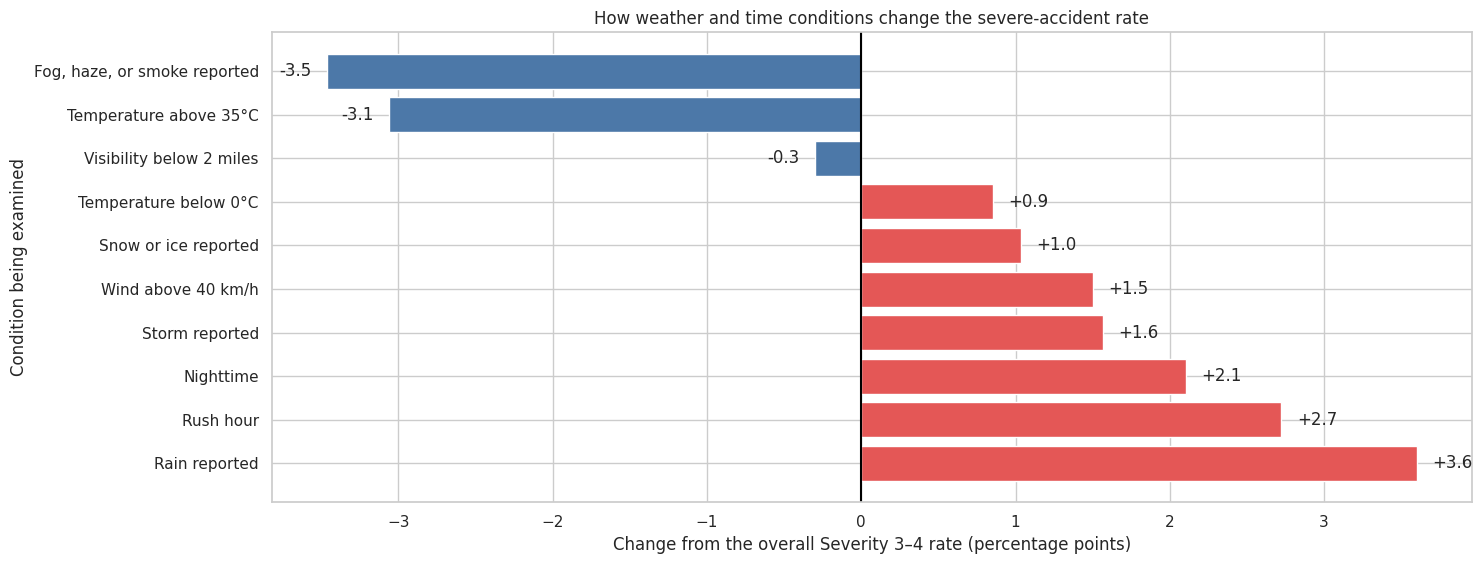

In [15]:
baseline=weather_df["Is_Severe"].mean()*100
flag_columns=["Is_Night","Is_Rush_Hour","Is_Rain_Day","Is_Snow_or_Ice","Is_Low_Visibility_Weather","Is_Storm","Poor_Visibility","Extreme_Cold","Extreme_Hot","High_Wind"]
readable={"Is_Night":"Nighttime","Is_Rush_Hour":"Rush hour","Is_Rain_Day":"Rain reported","Is_Snow_or_Ice":"Snow or ice reported","Is_Low_Visibility_Weather":"Fog, haze, or smoke reported","Is_Storm":"Storm reported","Poor_Visibility":"Visibility below 2 miles","Extreme_Cold":"Temperature below 0°C","Extreme_Hot":"Temperature above 35°C","High_Wind":"Wind above 40 km/h"}
rows=[]
for col in flag_columns:
    source=time_df if col in time_df.columns else weather_df
    values=weather_df.loc[source[col]==1,"Is_Severe"]
    rate=values.mean()*100 if len(values) else np.nan
    rows.append({"Feature":readable[col],"Accident_Count":len(values),"Severe_Rate":rate,"Lift_vs_Baseline_Percentage_Points":rate-baseline})
flag_summary=pd.DataFrame(rows).sort_values("Lift_vs_Baseline_Percentage_Points",ascending=False)
fig,ax=plt.subplots(figsize=(15,5.8))
bars=ax.barh(flag_summary["Feature"],flag_summary["Lift_vs_Baseline_Percentage_Points"],color=["#e45756" if x>0 else "#4c78a8" for x in flag_summary["Lift_vs_Baseline_Percentage_Points"]])
ax.axvline(0,color="black"); ax.set_title("How weather and time conditions change the severe-accident rate"); ax.set_xlabel("Change from the overall Severity 3–4 rate (percentage points)"); ax.set_ylabel("Condition being examined")
for bar,value in zip(bars,flag_summary["Lift_vs_Baseline_Percentage_Points"]):
  ax.text(value+(0.1 if value>=0 else -0.1),bar.get_y()+bar.get_height()/2,f"{value:+.1f}",ha="left" if value>=0 else "right",va="center")
plt.tight_layout();
plt.show();
#display(flag_summary)

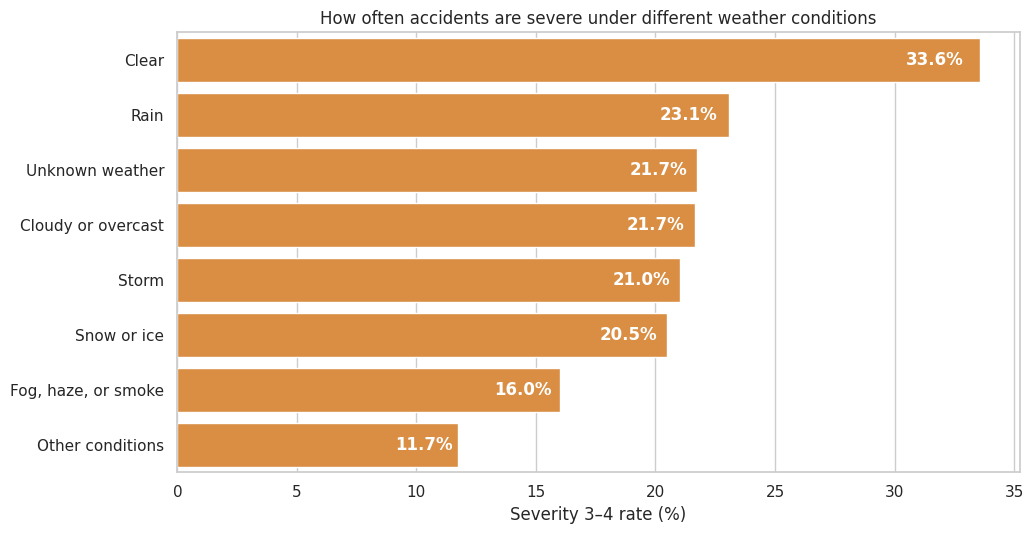

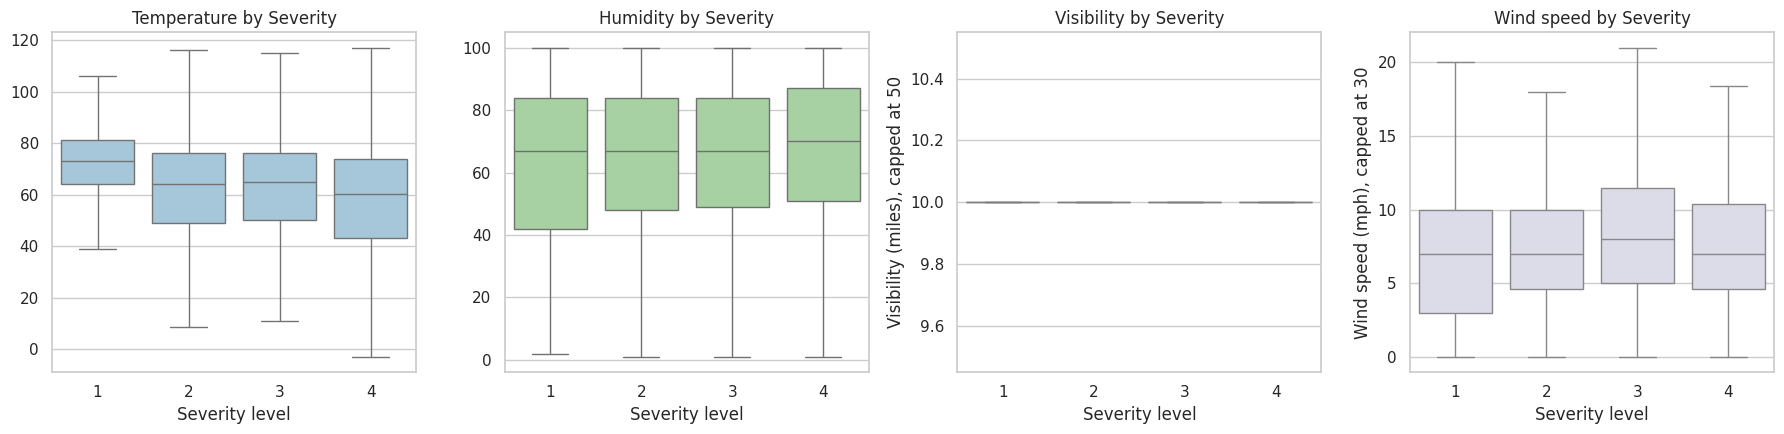

In [16]:
weather_summary = (
    severity_table(weather_df, "Weather_Group")
    .sort_values("Severe_Rate", ascending=False)
)

names = {
    "Clear": "Clear",
    "Cloudy": "Cloudy or overcast",
    "Rain": "Rain",
    "Snow/Ice": "Snow or ice",
    "Low Visibility": "Fog, haze, or smoke",
    "Storm": "Storm",
    "Other": "Other conditions",
    "Unknown": "Unknown weather",
}

weather_summary["Weather_Description"] = (
    weather_summary["Weather_Group"].map(names)
)

fig, ax = plt.subplots(figsize=(10.5, 5.5))

bars = sns.barplot(
    data=weather_summary,
    y="Weather_Description",
    x="Severe_Rate",
    color="#f28e2b",
    ax=ax,
)

ax.set_title(
    "How often accidents are severe under different weather conditions"
)
ax.set_xlabel("Severity 3–4 rate (%)")
ax.set_ylabel("")

for bar, value in zip(
    bars.patches,
    weather_summary["Severe_Rate"],
):
    ax.text(
        bar.get_width() * 0.98,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        ha="right",
        va="center",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

plot_numeric = numeric_df.copy()

plot_numeric["Visibility_plot"] = (
    plot_numeric["Visibility(mi)"].clip(upper=50)
)

plot_numeric["Wind_plot"] = (
    plot_numeric["Wind_Speed(mph)"].clip(upper=30)
)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

plot_settings = [
    (
        axes[0],
        "Temperature(F)",
        "Temperature by Severity",
        "#9ecae1",
    ),
    (
        axes[1],
        "Humidity(%)",
        "Humidity by Severity",
        "#a1d99b",
    ),
    (
        axes[2],
        "Visibility_plot",
        "Visibility by Severity",
        "#fdd0a2",
    ),
    (
        axes[3],
        "Wind_plot",
        "Wind speed by Severity",
        "#dadaeb",
    ),
]

for ax, column, title, color in plot_settings:
    sns.boxplot(
        data=plot_numeric,
        x="Severity",
        y=column,
        order=SEVERITY_ORDER,
        ax=ax,
        color=color,
        showfliers=False,
    )

    ax.set_title(title)
    ax.set_xlabel("Severity level")
    ax.set_ylabel("")

axes[2].set_ylabel("Visibility (miles), capped at 50")
axes[3].set_ylabel("Wind speed (mph), capped at 30")

plt.tight_layout()
plt.show()

## 6. Analysis B — geography and road infrastructure

In [17]:
geo_parts, infra_parts = [], []

rows_seen = 0
geo_usecols = ["Severity", "State"] + TRAFFIC_COLUMNS

# Read directly because read_chunks() always expects Start_Time.
for chunk in pd.read_csv(
    DATA_PATH,
    usecols=geo_usecols,
    chunksize=CHUNK_SIZE,
    low_memory=True,
    on_bad_lines="warn",
):
    if USE_SAMPLE and rows_seen >= SAMPLE_N:
        break

    if USE_SAMPLE:
        chunk = chunk.iloc[:SAMPLE_N - rows_seen].copy()

    rows_seen += len(chunk)

    for c in TRAFFIC_COLUMNS:
        chunk[c] = bool_to_int(chunk[c])

    chunk["Severity"] = pd.to_numeric(chunk["Severity"], errors="coerce")
    chunk["Is_Severe"] = (chunk["Severity"] >= 3).astype("int8")
    chunk["Traffic_Feature_Count"] = chunk[TRAFFIC_COLUMNS].sum(axis=1)
    chunk["No_Traffic_Control"] = (
        chunk["Traffic_Feature_Count"] == 0
    ).astype("int8")

    geo_parts.append(
        chunk[["Severity", "Is_Severe", "State"]]
    )

    infra_parts.append(
        chunk[
            [
                "Severity",
                "Is_Severe",
                "Traffic_Feature_Count",
                "No_Traffic_Control",
            ] + TRAFFIC_COLUMNS
        ]
    )

geo_df = pd.concat(geo_parts, ignore_index=True)
infra_df = pd.concat(infra_parts, ignore_index=True)

state_summary = severity_table(geo_df, "State")

state_plot = (
    state_summary[state_summary["Accident_Count"] >= 1000]
    .sort_values("Severe_Rate", ascending=False)
    .head(15)
)

display(state_plot)

,State,Accident_Count,Average_Severity,Severe_Rate,Share_of_Accidents
37,RI,16971,2.458,46.238,0.220
9,GA,169234,2.507,43.739,2.190
15,KY,32254,2.454,42.500,0.417
46,WI,34688,2.474,37.673,0.449
4,CO,90885,2.444,37.201,1.176
12,IL,168958,2.383,36.734,2.186
22,MO,77323,2.400,36.583,1.001
10,IA,26307,2.419,34.299,0.340
30,NM,10325,2.372,33.143,0.134
13,IN,67224,2.398,31.956,0.870


In [18]:
state_plot=state_summary[state_summary["Accident_Count"]>=1000].sort_values("Severe_Rate",ascending=False).copy()
state_plot["Severe_Rate_Label"]=state_plot["Severe_Rate"].map(lambda x:f"{x:.1f}%")
fig_rate=px.bar(state_plot,x="State",y="Severe_Rate",color="Severe_Rate",color_continuous_scale="YlOrRd",text="Severe_Rate_Label",hover_data={"State":True,"Accident_Count":":,","Severe_Rate":":.1f","Average_Severity":":.2f","Severe_Rate_Label":False},title="How often accidents are severe in each state",labels={"State":"State","Severe_Rate":"Severity 3–4 rate (%)","Accident_Count":"Number of accidents","Average_Severity":"Average Severity"})
fig_rate.update_traces(textposition="outside",texttemplate="%{text}"); fig_rate.update_layout(xaxis_tickangle=-45,showlegend=False,height=650); fig_rate.show()
fig_volume=px.bar(state_plot.sort_values("Accident_Count",ascending=False),x="State",y="Accident_Count",color="Accident_Count",color_continuous_scale="Blues",text_auto=".3s",hover_data={"State":True,"Accident_Count":":,","Severe_Rate":":.1f"},title="Number of recorded accidents by state",labels={"State":"State","Accident_Count":"Number of accidents","Severe_Rate":"Severity 3–4 rate (%)"})
fig_volume.update_layout(xaxis_tickangle=-45,showlegend=False,height=650); fig_volume.show(); #display(state_plot[["State","Accident_Count","Severe_Rate","Average_Severity"]])

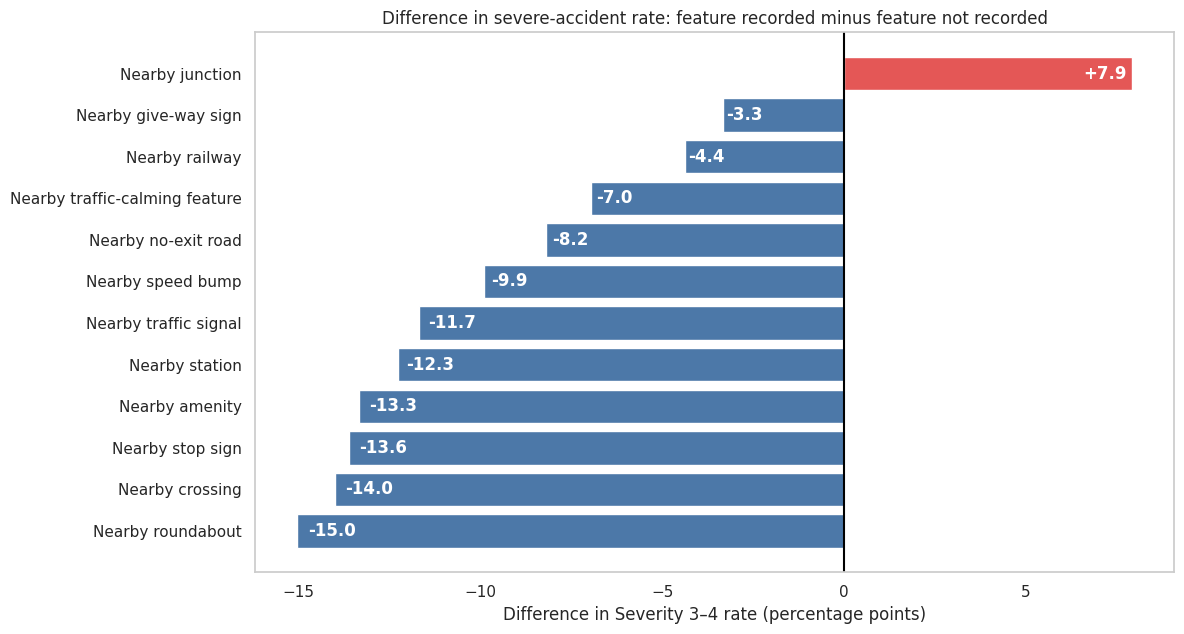

In [19]:
infra_rows = []

feature_names = {
    "Amenity": "Nearby amenity",
    "Bump": "Nearby speed bump",
    "Crossing": "Nearby crossing",
    "Give_Way": "Nearby give-way sign",
    "Junction": "Nearby junction",
    "No_Exit": "Nearby no-exit road",
    "Railway": "Nearby railway",
    "Roundabout": "Nearby roundabout",
    "Station": "Nearby station",
    "Stop": "Nearby stop sign",
    "Traffic_Calming": "Nearby traffic-calming feature",
    "Traffic_Signal": "Nearby traffic signal",
    "Turning_Loop": "Turning loop",
}

for col in TRAFFIC_COLUMNS:
    for present, label in [
        (1, "Feature recorded"),
        (0, "Feature not recorded"),
    ]:
        subset = infra_df[infra_df[col] == present]

        infra_rows.append(
            {
                "Feature": col,
                "Condition": label,
                "Accident_Count": len(subset),
                "Severe_Rate": (
                    subset["Is_Severe"].mean() * 100
                    if len(subset)
                    else np.nan
                ),
            }
        )

infra_summary = pd.DataFrame(infra_rows)

infra_wide = infra_summary.pivot(
    index="Feature",
    columns="Condition",
    values="Severe_Rate",
)

infra_wide["Difference_Present_minus_Absent"] = (
    infra_wide["Feature recorded"]
    - infra_wide["Feature not recorded"]
)

infra_wide["Readable_Feature"] = infra_wide.index.map(
    feature_names.get
)

infra_wide = infra_wide.sort_values(
    "Difference_Present_minus_Absent"
)

fig, ax = plt.subplots(figsize=(12, 6.5))

values = infra_wide["Difference_Present_minus_Absent"]

bars = ax.barh(
    infra_wide["Readable_Feature"],
    values,
    color=[
        "#e45756" if value > 0 else "#4c78a8"
        for value in values
    ],
)

ax.axvline(0, color="black")

ax.set_title(
    "Difference in severe-accident rate: feature recorded minus feature not recorded"
)

ax.set_xlabel(
    "Difference in Severity 3–4 rate (percentage points)"
)

ax.set_ylabel("")

ax.grid(False)

for bar, value in zip(bars, values):
    if value >= 0:
        x_position = value * 0.98
        alignment = "right"
    else:
        x_position = value * 0.98
        alignment = "left"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.1f}",
        ha=alignment,
        va="center",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 7. Advanced feature: weather conditions by state

This section calculates the share of each state's accident records in each weather group, the most common weather group, weather diversity, and the severe-accident rate within each state-weather group. This helps separate a state's usual weather mix from the relationship between weather and Severity.

In [20]:
weather_state_parts=[]
rows_seen=0
weather_state_usecols=["State","Weather_Condition","Severity"]
for chunk in pd.read_csv(DATA_PATH,usecols=weather_state_usecols,chunksize=CHUNK_SIZE,low_memory=True,on_bad_lines="warn"):
    if USE_SAMPLE and rows_seen>=SAMPLE_N: break
    if USE_SAMPLE: chunk=chunk.iloc[:SAMPLE_N-rows_seen].copy()
    rows_seen+=len(chunk); chunk["Weather_Group"]=chunk["Weather_Condition"].map(classify_weather); chunk["Is_Severe"]=(pd.to_numeric(chunk["Severity"],errors="coerce")>=3).astype("int8")
    weather_state_parts.append(chunk[["State","Weather_Group","Severity","Is_Severe"]])
weather_state_df=pd.concat(weather_state_parts,ignore_index=True)
weather_state_counts=weather_state_df.groupby(["State","Weather_Group"],dropna=False).agg(Accident_Count=("Severity","size"),Severe_Rate=("Is_Severe","mean")).reset_index(); weather_state_counts["Severe_Rate"]*=100
state_totals=weather_state_counts.groupby("State")["Accident_Count"].transform("sum"); weather_state_counts["Share_of_State_Accidents"]=weather_state_counts["Accident_Count"]/state_totals*100
weather_state_pivot=weather_state_counts.pivot(index="State",columns="Weather_Group",values="Share_of_State_Accidents").fillna(0); weather_state_pivot["Most_Common_Weather"]=weather_state_pivot.idxmax(axis=1)
probabilities=weather_state_pivot.drop(columns=["Most_Common_Weather"])/100; weather_state_pivot["Weather_Diversity"]=-(probabilities*np.log(probabilities.replace(0,np.nan))).sum(axis=1)
state_weather_features=weather_state_pivot.reset_index().merge(state_summary[["State","Accident_Count","Severe_Rate"]],on="State",how="left",suffixes=("","_All_Weather")); #display(state_weather_features.head(15))

In [21]:
heatmap_data=weather_state_pivot.drop(columns=["Most_Common_Weather","Weather_Diversity"],errors="ignore")
fig_heatmap=px.imshow(heatmap_data,aspect="auto",color_continuous_scale="YlGnBu",text_auto=".1f",labels={"x":"Weather condition group","y":"State","color":"Share of state accidents (%)"},title="Weather-condition mix within each state's accident records"); fig_heatmap.update_layout(height=1100); fig_heatmap.show()
selected_states=state_weather_features.sort_values("Accident_Count",ascending=False).head(10)["State"].tolist(); selected_weather=weather_state_counts[weather_state_counts["State"].isin(selected_states)].copy()
fig_weather_state=px.bar(selected_weather,x="State",y="Share_of_State_Accidents",color="Weather_Group",barmode="stack",text_auto=".1f",hover_data={"Accident_Count":":,","Severe_Rate":":.1f","Share_of_State_Accidents":":.1f"},title="Weather-condition mix for the ten states with the most accident records",labels={"State":"State","Share_of_State_Accidents":"Share of state's accident records (%)","Weather_Group":"Weather condition group","Severe_Rate":"Severity 3–4 rate (%)"}); fig_weather_state.update_layout(height=650); fig_weather_state.show()

## 8. Optional comparison with public climate data

NOAA's 1991–2020 U.S. Climate Normals provide public station-level averages and frequencies for precipitation, snowfall, temperature, and related conditions. They describe typical climate conditions, while the accident file describes weather reported at accident locations. These are different populations, so this comparison is contextual rather than causal.

The optional comparison expects a prepared state-level NOAA CSV with `State`, `Annual_Precipitation_Days`, `Annual_Snowfall`, and `Annual_Precipitation`. The official source is NOAA NCEI's U.S. Climate Normals page: https://www.ncei.noaa.gov/products/land-based-station/us-climate-normals

Accident records processed: 7,728,394
Records retained after weather cleaning: 6,502,836
Unknown or other weather records removed: 150,466
Retained records matched to NOAA data: 6,502,836 (100.0%)


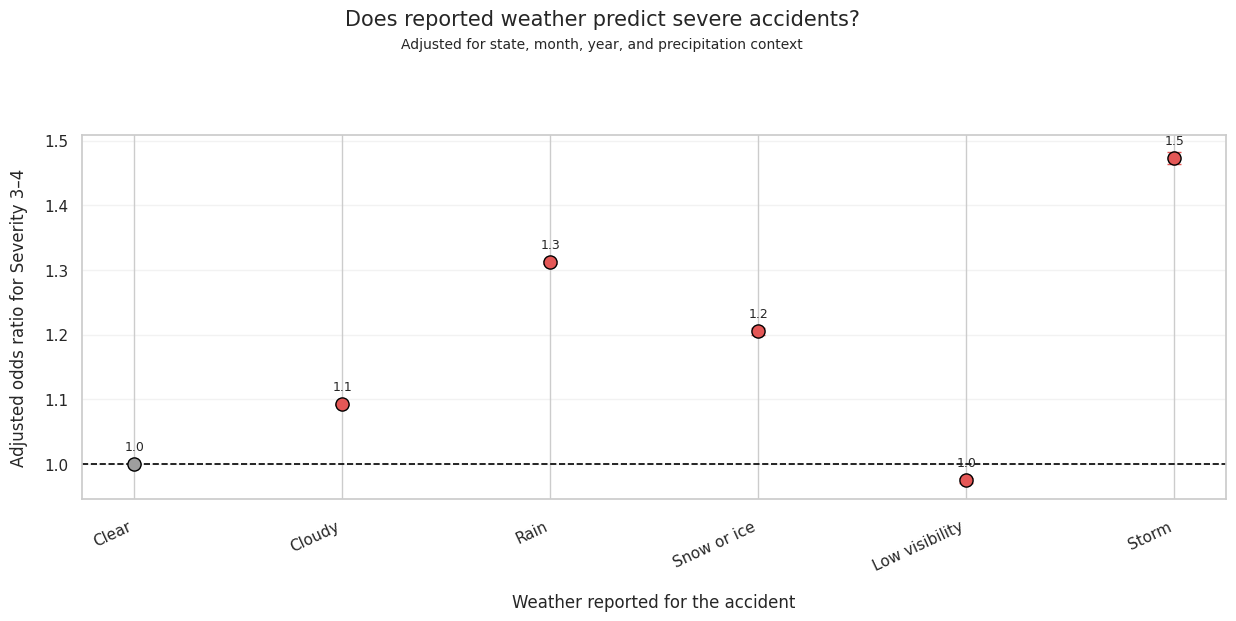

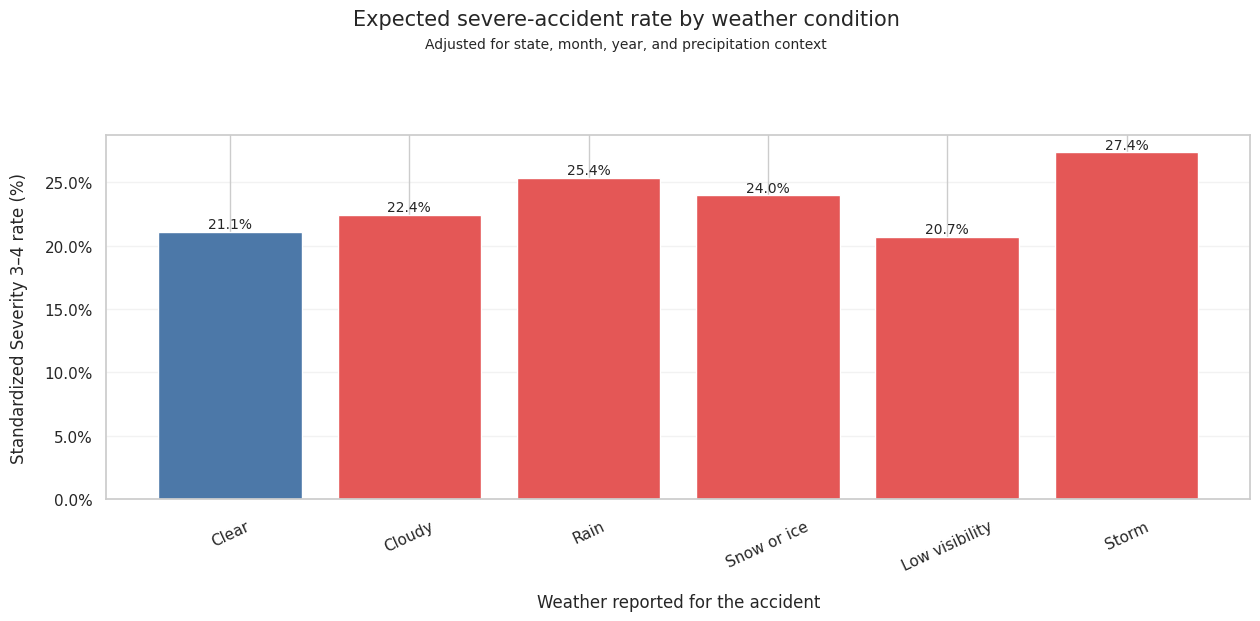

Statistical conclusion
---------------------
Weather condition statistically significant: YES
Overall weather-condition result: p < 0.001

Individual weather conditions compared with Clear:
Clear: reference condition
Cloudy: adjusted odds ratio = 1.092, 95% CI = [1.091, 1.093], statistically significant = YES, p < 0.001
Rain: adjusted odds ratio = 1.312, 95% CI = [1.309, 1.314], statistically significant = YES, p < 0.001
Snow or ice: adjusted odds ratio = 1.205, 95% CI = [1.199, 1.210], statistically significant = YES, p < 0.001
Low visibility: adjusted odds ratio = 0.975, 95% CI = [0.971, 0.979], statistically significant = YES, p < 0.001
Storm: adjusted odds ratio = 1.474, 95% CI = [1.464, 1.483], statistically significant = YES, p < 0.001

An adjusted odds ratio near 1 means that the weather condition does not meaningfully differ from Clear after accounting for state, month, year, and precipitation context.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# State codes used by NOAA
# ------------------------------------------------------------

state_codes = {
    "AL": 1, "AZ": 2, "AR": 3, "CA": 4, "CO": 5,
    "CT": 6, "DE": 7, "FL": 8, "GA": 9, "ID": 10,
    "IL": 11, "IN": 12, "IA": 13, "KS": 14, "KY": 15,
    "LA": 16, "ME": 17, "MD": 18, "MA": 19, "MI": 20,
    "MN": 21, "MS": 22, "MO": 23, "MT": 24, "NE": 25,
    "NV": 26, "NH": 27, "NJ": 28, "NM": 29, "NY": 30,
    "NC": 31, "ND": 32, "OH": 33, "OK": 34, "OR": 35,
    "PA": 36, "RI": 37, "SC": 38, "SD": 39, "TN": 40,
    "TX": 41, "UT": 42, "VT": 43, "VA": 44, "WA": 45,
    "WV": 46, "WI": 47, "WY": 48, "AK": 50
}


# ------------------------------------------------------------
# Classify weather reported for each accident
# ------------------------------------------------------------

def classify_event_weather(value):
    if pd.isna(value):
        return "Unknown"

    text = str(value).lower()

    if any(word in text for word in [
        "thunder", "tstorm", "storm", "hurricane", "tornado"
    ]):
        return "Storm"

    if any(word in text for word in [
        "snow", "sleet", "ice", "freezing", "wintry"
    ]):
        return "Snow or ice"

    if any(word in text for word in [
        "rain", "drizzle", "shower"
    ]):
        return "Rain"

    if any(word in text for word in [
        "fog", "haze", "smoke", "mist", "dust"
    ]):
        return "Low visibility"

    if any(word in text for word in [
        "clear", "fair"
    ]):
        return "Clear"

    if any(word in text for word in [
        "cloud", "overcast"
    ]):
        return "Cloudy"

    return "Other or unknown"


# ------------------------------------------------------------
# Read NOAA precipitation data
# ------------------------------------------------------------

actual_url = (
    "https://www.ncei.noaa.gov/pub/data/cirs/climdiv/"
    "climdiv-pcpnst-v1.0.0-20260904"
)

normal_url = (
    "https://www.ncei.noaa.gov/pub/data/cirs/climdiv/"
    "climdiv-norm-pcpnst-v1.0.0-20260904"
)

noaa_columns = [
    "State_Code",
    "Division_Number",
    "Element_Code",
    "Year_or_Normal_Code",
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

column_widths = [3, 1, 2, 4] + [7] * 12

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_numbers = {
    month: number for number, month in enumerate(month_names, 1)
}


# ------------------------------------------------------------
# Actual monthly precipitation by state and year
# ------------------------------------------------------------

noaa_actual = pd.read_fwf(
    actual_url,
    widths=column_widths,
    names=noaa_columns,
    header=None
)

noaa_actual = noaa_actual[
    (noaa_actual["Division_Number"] == 0) &
    (noaa_actual["Element_Code"] == 1)
].copy()

noaa_actual = noaa_actual.rename(
    columns={"Year_or_Normal_Code": "Year"}
)

noaa_actual["Year"] = pd.to_numeric(
    noaa_actual["Year"],
    errors="coerce"
)

noaa_actual = noaa_actual.melt(
    id_vars=["State_Code", "Year"],
    value_vars=month_names,
    var_name="Month_Name",
    value_name="Actual_Precipitation_Inches"
)

noaa_actual["Month"] = noaa_actual["Month_Name"].map(month_numbers)

noaa_actual.loc[
    ~noaa_actual["Actual_Precipitation_Inches"].between(0, 100),
    "Actual_Precipitation_Inches"
] = np.nan


# ------------------------------------------------------------
# 1991–2020 monthly precipitation normals
# ------------------------------------------------------------

noaa_normal = pd.read_fwf(
    normal_url,
    widths=column_widths,
    names=noaa_columns,
    header=None
)

noaa_normal = noaa_normal[
    (noaa_normal["Division_Number"] == 0) &
    (noaa_normal["Element_Code"] == 1) &
    (noaa_normal["Year_or_Normal_Code"] == 10)
].copy()

noaa_normal = noaa_normal.melt(
    id_vars=["State_Code"],
    value_vars=month_names,
    var_name="Month_Name",
    value_name="Normal_Precipitation_Inches"
)

noaa_normal["Month"] = noaa_normal["Month_Name"].map(month_numbers)

noaa_normal.loc[
    ~noaa_normal["Normal_Precipitation_Inches"].between(0, 100),
    "Normal_Precipitation_Inches"
] = np.nan


# ------------------------------------------------------------
# Process accident data in chunks
# ------------------------------------------------------------

aggregation_parts = []

rows_seen = 0
clean_weather_rows = 0
removed_weather_rows = 0
rows_with_noaa_match = 0

usecols = [
    "State",
    "Start_Time",
    "Severity",
    "Weather_Condition"
]

retained_weather_groups = [
    "Clear",
    "Cloudy",
    "Rain",
    "Snow or ice",
    "Low visibility",
    "Storm"
]

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=usecols,
    chunksize=CHUNK_SIZE,
    low_memory=False
):
    if USE_SAMPLE and rows_seen >= SAMPLE_N:
        break

    if USE_SAMPLE:
        chunk = chunk.iloc[:SAMPLE_N - rows_seen].copy()

    rows_seen += len(chunk)

    chunk["Start_Time"] = pd.to_datetime(
        chunk["Start_Time"],
        errors="coerce"
    )

    chunk["Severity"] = pd.to_numeric(
        chunk["Severity"],
        errors="coerce"
    )

    chunk["State_Code"] = chunk["State"].map(state_codes)
    chunk["Year"] = chunk["Start_Time"].dt.year
    chunk["Month"] = chunk["Start_Time"].dt.month

    chunk = chunk.dropna(
        subset=[
            "State_Code",
            "Year",
            "Month",
            "Severity"
        ]
    ).copy()

    chunk["State_Code"] = chunk["State_Code"].astype(int)
    chunk["Year"] = chunk["Year"].astype(int)
    chunk["Month"] = chunk["Month"].astype(int)

    chunk["Severity_Group"] = np.where(
        chunk["Severity"] >= 3,
        "Severity 3–4",
        "Severity 1–2"
    )

    chunk["Weather_Group"] = (
        chunk["Weather_Condition"]
        .apply(classify_event_weather)
    )

    # Remove Unknown and Other weather categories
    weather_mask = chunk["Weather_Group"].isin(
        retained_weather_groups
    )

    removed_weather_rows += (~weather_mask).sum()

    chunk = chunk[weather_mask].copy()

    if chunk.empty:
        continue

    clean_weather_rows += len(chunk)

    # Match actual precipitation
    chunk = chunk.merge(
        noaa_actual[
            [
                "State_Code",
                "Year",
                "Month",
                "Actual_Precipitation_Inches"
            ]
        ],
        on=["State_Code", "Year", "Month"],
        how="left"
    )

    # Match monthly precipitation normal
    chunk = chunk.merge(
        noaa_normal[
            [
                "State_Code",
                "Month",
                "Normal_Precipitation_Inches"
            ]
        ],
        on=["State_Code", "Month"],
        how="left"
    )

    valid_noaa = (
        chunk["Actual_Precipitation_Inches"].notna()
        & chunk["Normal_Precipitation_Inches"].notna()
    )

    rows_with_noaa_match += valid_noaa.sum()

    # Preserve records without NOAA matches
    chunk["Precipitation_Context"] = np.select(
        [
            ~valid_noaa,
            chunk["Actual_Precipitation_Inches"]
            > chunk["Normal_Precipitation_Inches"]
        ],
        [
            "NOAA data unavailable",
            "Above-normal month"
        ],
        default="At or below normal"
    )

    chunk["Is_Severe"] = (
        chunk["Severity"] >= 3
    ).astype(int)

    aggregation_parts.append(
        chunk.groupby(
            [
                "State",
                "Year",
                "Month",
                "Weather_Group",
                "Precipitation_Context"
            ],
            as_index=False
        ).agg(
            Accident_Count=("Is_Severe", "size"),
            Severe_Accident_Count=("Is_Severe", "sum")
        )
    )


# ------------------------------------------------------------
# Combine all chunks
# ------------------------------------------------------------

accident_groups = (
    pd.concat(aggregation_parts, ignore_index=True)
    .groupby(
        [
            "State",
            "Year",
            "Month",
            "Weather_Group",
            "Precipitation_Context"
        ],
        as_index=False
    )[
        [
            "Accident_Count",
            "Severe_Accident_Count"
        ]
    ]
    .sum()
)

accident_groups["Severe_Fraction"] = (
    accident_groups["Severe_Accident_Count"]
    / accident_groups["Accident_Count"]
)

print(f"Accident records processed: {rows_seen:,}")
print(f"Records retained after weather cleaning: {clean_weather_rows:,}")
print(f"Unknown or other weather records removed: {removed_weather_rows:,}")
print(
    f"Retained records matched to NOAA data: "
    f"{rows_with_noaa_match:,} "
    f"({rows_with_noaa_match / clean_weather_rows * 100:.1f}%)"
)


# ------------------------------------------------------------
# Prepare statistical model
# ------------------------------------------------------------

model_data = accident_groups.copy()

for column in [
    "Weather_Group",
    "State",
    "Month",
    "Year",
    "Precipitation_Context"
]:
    model_data[column] = model_data[column].astype(str)


# ------------------------------------------------------------
# Statistical model
# ------------------------------------------------------------

full_formula = (
    "Severe_Fraction ~ "
    "C(Weather_Group, Treatment(reference='Clear')) + "
    "C(State) + "
    "C(Month) + "
    "C(Year) + "
    "C(Precipitation_Context)"
)

reduced_formula = (
    "Severe_Fraction ~ "
    "C(State) + "
    "C(Month) + "
    "C(Year) + "
    "C(Precipitation_Context)"
)

full_model = smf.glm(
    formula=full_formula,
    data=model_data,
    family=sm.families.Binomial(),
    freq_weights=model_data["Accident_Count"]
).fit(cov_type="HC1")

reduced_model = smf.glm(
    formula=reduced_formula,
    data=model_data,
    family=sm.families.Binomial(),
    freq_weights=model_data["Accident_Count"]
).fit()


# ------------------------------------------------------------
# Overall weather significance test
# ------------------------------------------------------------

likelihood_ratio = 2 * (
    full_model.llf - reduced_model.llf
)

degrees_of_freedom = int(
    full_model.df_model - reduced_model.df_model
)

weather_overall_p = chi2.sf(
    likelihood_ratio,
    degrees_of_freedom
)


def format_p_value(value):
    if value < 0.001:
        return "p < 0.001"
    return f"p = {value:.3f}"


# ------------------------------------------------------------
# Adjusted odds ratios
# ------------------------------------------------------------

weather_effects = []

for term in full_model.params.index:

    if term.startswith("C(Weather_Group"):

        label = term.split("[T.", 1)[1].rstrip("]")

        coefficient = full_model.params[term]
        standard_error = full_model.bse[term]

        weather_effects.append({
            "Weather_Group": label,
            "Adjusted_Odds_Ratio": np.exp(coefficient),
            "Lower_95_CI": np.exp(
                coefficient - 1.96 * standard_error
            ),
            "Upper_95_CI": np.exp(
                coefficient + 1.96 * standard_error
            ),
            "P_Value": full_model.pvalues[term]
        })

weather_effects = pd.DataFrame(weather_effects)

weather_effects = pd.concat(
    [
        pd.DataFrame([{
            "Weather_Group": "Clear",
            "Adjusted_Odds_Ratio": 1.0,
            "Lower_95_CI": 1.0,
            "Upper_95_CI": 1.0,
            "P_Value": np.nan
        }]),
        weather_effects
    ],
    ignore_index=True
)

weather_order = [
    "Clear",
    "Cloudy",
    "Rain",
    "Snow or ice",
    "Low visibility",
    "Storm"
]

weather_effects["Sort_Order"] = (
    weather_effects["Weather_Group"]
    .map({
        name: position
        for position, name in enumerate(weather_order)
    })
)

weather_effects = (
    weather_effects
    .sort_values("Sort_Order")
    .drop(columns="Sort_Order")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Chart 1: adjusted odds ratios
# ------------------------------------------------------------

plot_effects = weather_effects.copy()

x = np.arange(len(plot_effects))

colors = []

for _, row in plot_effects.iterrows():

    if (
        row["Lower_95_CI"] > 1
        or row["Upper_95_CI"] < 1
    ):
        colors.append("#e45756")
    else:
        colors.append("#9e9e9e")


fig, ax = plt.subplots(figsize=(13, 7))

for position, (_, row), color in zip(
    x,
    plot_effects.iterrows(),
    colors
):

    odds_ratio = row["Adjusted_Odds_Ratio"]

    lower_error = (
        odds_ratio
        - row["Lower_95_CI"]
    )

    upper_error = (
        row["Upper_95_CI"]
        - odds_ratio
    )

    if all(np.isfinite([
        odds_ratio,
        lower_error,
        upper_error
    ])):

        ax.errorbar(
            position,
            odds_ratio,
            yerr=[
                [lower_error],
                [upper_error]
            ],
            fmt="none",
            ecolor=color,
            elinewidth=2,
            capsize=5
        )

        ax.scatter(
            position,
            odds_ratio,
            s=90,
            color=color,
            edgecolor="black",
            zorder=3
        )

        ax.annotate(
            f"{odds_ratio:.1f}",
            (position, odds_ratio),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )


ax.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1.2
)

ax.set_xticks(x)

ax.set_xticklabels(
    plot_effects["Weather_Group"],
    rotation=25,
    ha="right"
)

ax.set_ylabel(
    "Adjusted odds ratio for Severity 3–4",
    labelpad=12
)

ax.set_xlabel(
    "Weather reported for the accident",
    labelpad=14
)

ax.yaxis.set_major_formatter(
    FormatStrFormatter("%.1f")
)

fig.suptitle(
    "Does reported weather predict severe accidents?",
    fontsize=15,
    y=0.98
)

fig.text(
    0.5,
    0.925,
    "Adjusted for state, month, year, and precipitation context",
    ha="center",
    fontsize=10
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.tick_params(
    axis="x",
    pad=8
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.28,
    top=0.80
)

plt.show()


# ------------------------------------------------------------
# Standardized predicted severe-accident rates
# ------------------------------------------------------------

standardization_base = (
    accident_groups
    .groupby(
        [
            "State",
            "Year",
            "Month",
            "Precipitation_Context"
        ],
        as_index=False
    )["Accident_Count"]
    .sum()
)

standardization_base["State"] = (
    standardization_base["State"].astype(str)
)

standardization_base["Month"] = (
    standardization_base["Month"].astype(str)
)

standardization_base["Year"] = (
    standardization_base["Year"].astype(str)
)

standardization_base["Precipitation_Context"] = (
    standardization_base["Precipitation_Context"].astype(str)
)

standardized_rates = []

for weather in weather_order:

    counterfactual = standardization_base.copy()
    counterfactual["Weather_Group"] = weather

    predicted_probability = full_model.predict(
        counterfactual
    )

    standardized_rate = np.average(
        predicted_probability,
        weights=counterfactual["Accident_Count"]
    ) * 100

    standardized_rates.append({
        "Weather_Group": weather,
        "Standardized_Severe_Rate": standardized_rate
    })

standardized_rates = pd.DataFrame(standardized_rates)

bar_colors = [
    "#4c78a8"
    if weather == "Clear"
    else "#e45756"
    for weather in standardized_rates["Weather_Group"]
]


# ------------------------------------------------------------
# Chart 2: standardized severe-accident rates
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    standardized_rates["Weather_Group"],
    standardized_rates["Standardized_Severe_Rate"],
    color=bar_colors
)

for bar, value in zip(
    bars,
    standardized_rates["Standardized_Severe_Rate"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylabel(
    "Standardized Severity 3–4 rate (%)",
    labelpad=12
)

ax.set_xlabel(
    "Weather reported for the accident",
    labelpad=14
)

ax.yaxis.set_major_formatter(
    FormatStrFormatter("%.1f%%")
)

ax.tick_params(
    axis="x",
    rotation=25,
    pad=8
)

fig.suptitle(
    "Expected severe-accident rate by weather condition",
    fontsize=15,
    y=0.98
)

fig.text(
    0.5,
    0.925,
    "Adjusted for state, month, year, and precipitation context",
    ha="center",
    fontsize=10
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.28,
    top=0.80
)

plt.show()


# ------------------------------------------------------------
# Plain-language conclusion
# ------------------------------------------------------------

print("Statistical conclusion")
print("---------------------")

print(
    "Weather condition statistically significant: "
    f"{'YES' if weather_overall_p < 0.05 else 'NO'}"
)

print(
    f"Overall weather-condition result: "
    f"{format_p_value(weather_overall_p)}"
)

print()
print("Individual weather conditions compared with Clear:")

for _, row in weather_effects.iterrows():

    if row["Weather_Group"] == "Clear":
        print("Clear: reference condition")
        continue

    significance = (
        "YES"
        if row["P_Value"] < 0.05
        else "NO"
    )

    print(
        f"{row['Weather_Group']}: "
        f"adjusted odds ratio = {row['Adjusted_Odds_Ratio']:.3f}, "
        f"95% CI = "
        f"[{row['Lower_95_CI']:.3f}, "
        f"{row['Upper_95_CI']:.3f}], "
        f"statistically significant = {significance}, "
        f"{format_p_value(row['P_Value'])}"
    )
print()
print(
    "An adjusted odds ratio near 1 means that the weather condition "
    "does not meaningfully differ from Clear after accounting for "
    "state, month, year, and precipitation context."
)

In [23]:
# ============================================================
# Exposure-adjusted hourly weather comparison for Severity 3–4
# ============================================================

import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm


# -----------------------------
# Settings
# -----------------------------

ACCIDENT_FILE = DATA_PATH if "DATA_PATH" in globals() else "/content/US_Accidents_March23.csv"
CHUNK_SIZE_LOCAL = int(globals().get("CHUNK_SIZE", 250_000))

USE_SAMPLE_FOR_THIS_CELL = False
SAMPLE_N_LOCAL = int(globals().get("SAMPLE_N", 500_000))

NOAA_STATIONS_PER_STATE = 1
NOAA_WORKERS = 8
NOAA_CACHE_DIR = Path("/content/ghcnh_processed_hourly_local")
NOAA_CACHE_DIR.mkdir(parents=True, exist_ok=True)

YEARS = list(range(2016, 2024))
MIN_SEVERE_ACCIDENTS_PER_STATE_MONTH_HOUR = 25
MIN_WEATHER_STATIONS_PER_STATE_MONTH_HOUR = 1

NOAA_STATION_LIST_URL = (
    "https://www.ncei.noaa.gov/oa/"
    "global-historical-climatology-network/hourly/doc/ghcnh-station-list.csv"
)

NOAA_BASE_URL = (
    "https://www.ncei.noaa.gov/oa/"
    "global-historical-climatology-network/hourly/access/by-year"
)


# -----------------------------
# Time-zone and weather helpers
# -----------------------------

STATE_TIMEZONE_FALLBACK = {
    "AL": "America/Chicago",
    "AK": "America/Anchorage",
    "AZ": "America/Phoenix",
    "AR": "America/Chicago",
    "CA": "America/Los_Angeles",
    "CO": "America/Denver",
    "CT": "America/New_York",
    "DE": "America/New_York",
    "DC": "America/New_York",
    "FL": "America/New_York",
    "GA": "America/New_York",
    "HI": "Pacific/Honolulu",
    "ID": "America/Denver",
    "IL": "America/Chicago",
    "IN": "America/Indiana/Indianapolis",
    "IA": "America/Chicago",
    "KS": "America/Chicago",
    "KY": "America/New_York",
    "LA": "America/Chicago",
    "ME": "America/New_York",
    "MD": "America/New_York",
    "MA": "America/New_York",
    "MI": "America/Detroit",
    "MN": "America/Chicago",
    "MS": "America/Chicago",
    "MO": "America/Chicago",
    "MT": "America/Denver",
    "NE": "America/Chicago",
    "NV": "America/Los_Angeles",
    "NH": "America/New_York",
    "NJ": "America/New_York",
    "NM": "America/Denver",
    "NY": "America/New_York",
    "NC": "America/New_York",
    "ND": "America/Chicago",
    "OH": "America/New_York",
    "OK": "America/Chicago",
    "OR": "America/Los_Angeles",
    "PA": "America/New_York",
    "RI": "America/New_York",
    "SC": "America/New_York",
    "SD": "America/Chicago",
    "TN": "America/Chicago",
    "TX": "America/Chicago",
    "UT": "America/Denver",
    "VT": "America/New_York",
    "VA": "America/New_York",
    "WA": "America/Los_Angeles",
    "WV": "America/New_York",
    "WI": "America/Chicago",
    "WY": "America/Denver",
}


def accident_time_to_local(frame):
    return pd.to_datetime(frame["Start_Time"], errors="coerce")


def classify_accident_weather(weather_series):
    text = (
        weather_series
        .fillna("")
        .astype("string")
        .str.lower()
        .str.strip()
    )

    adverse = text.str.contains(
        r"rain|drizzle|shower|snow|ice|sleet|freezing|fog|mist|haze|smoke|"
        r"thunder|storm|hail|dust|sand|blizzard|wind",
        regex=True,
        na=False,
    )

    normal = text.str.contains(
        r"clear|fair|cloudy|overcast|partly cloudy|mostly cloudy|scattered clouds",
        regex=True,
        na=False,
    ) & ~adverse

    result = pd.Series(
        pd.NA,
        index=weather_series.index,
        dtype="string",
    )

    result.loc[normal] = "Normal or overcast"
    result.loc[adverse] = "Worse weather"

    return result


# -----------------------------
# Read accident records
# -----------------------------

required_accident_columns = [
    "Start_Time",
    "Timezone",
    "Severity",
    "State",
    "Weather_Condition",
    "Start_Lat",
    "Start_Lng",
]

accident_parts = []
location_parts = []
rows_seen = 0

for chunk in pd.read_csv(
    ACCIDENT_FILE,
    usecols=required_accident_columns,
    chunksize=CHUNK_SIZE_LOCAL,
    low_memory=False,
    on_bad_lines="warn",
):
    if USE_SAMPLE_FOR_THIS_CELL and rows_seen >= SAMPLE_N_LOCAL:
        break

    if USE_SAMPLE_FOR_THIS_CELL:
        remaining = SAMPLE_N_LOCAL - rows_seen
        chunk = chunk.iloc[:remaining].copy()

    rows_seen += len(chunk)

    chunk["_lat"] = pd.to_numeric(
        chunk["Start_Lat"],
        errors="coerce",
    )

    chunk["_lng"] = pd.to_numeric(
        chunk["Start_Lng"],
        errors="coerce",
    )

    location_parts.append(
        chunk.dropna(subset=["State"])
        .groupby("State", as_index=False)
        .agg(
            Latitude_Sum=("_lat", "sum"),
            Longitude_Sum=("_lng", "sum"),
            Location_Count=("_lat", "count"),
        )
    )

    chunk["_severity_num"] = pd.to_numeric(
        chunk["Severity"],
        errors="coerce",
    )

    chunk["Start_Local"] = accident_time_to_local(chunk)
    chunk["Year"] = chunk["Start_Local"].dt.year
    chunk["Month"] = chunk["Start_Local"].dt.month
    chunk["Hour"] = chunk["Start_Local"].dt.hour

    chunk["Accident_Weather_Group"] = classify_accident_weather(
        chunk["Weather_Condition"]
    )

    severe = chunk[
        (chunk["_severity_num"] >= 3)
        & chunk["Start_Local"].notna()
        & chunk["State"].notna()
    ].copy()

    if severe.empty:
        continue

    cell_keys = [
        "State",
        "Year",
        "Month",
        "Hour",
    ]

    total_severe = severe.groupby(
        cell_keys,
        observed=True,
    ).size()

    total_severe.name = "Severe_Accident_Count"

    known_weather = severe[
        "Accident_Weather_Group"
    ].notna()

    classified_severe = (
        severe.loc[known_weather]
        .groupby(
            cell_keys,
            observed=True,
        )
        .size()
    )

    classified_severe.name = (
        "Severe_Accidents_With_Known_Weather"
    )

    worse_severe = (
        severe.loc[known_weather]
        .assign(
            _worse=severe.loc[
                known_weather,
                "Accident_Weather_Group",
            ]
            .eq("Worse weather")
            .astype("int8")
        )
        .groupby(
            cell_keys,
            observed=True,
        )["_worse"]
        .sum()
    )

    worse_severe.name = (
        "Severe_Accidents_in_Worse_Weather"
    )

    accident_parts.append(
        pd.concat(
            [
                total_severe,
                classified_severe,
                worse_severe,
            ],
            axis=1,
        ).reset_index()
    )

if not accident_parts:
    raise ValueError(
        "No Severity 3–4 accident records with usable timestamps were found."
    )

accident_cells = (
    pd.concat(
        accident_parts,
        ignore_index=True,
    )
    .groupby(
        [
            "State",
            "Year",
            "Month",
            "Hour",
        ],
        as_index=False,
    )
    .sum(numeric_only=True)
)

for column in [
    "Severe_Accident_Count",
    "Severe_Accidents_With_Known_Weather",
    "Severe_Accidents_in_Worse_Weather",
]:
    accident_cells[column] = (
        accident_cells[column]
        .fillna(0)
        .astype("int64")
    )

location_summary = (
    pd.concat(
        location_parts,
        ignore_index=True,
    )
    .groupby(
        "State",
        as_index=False,
    )
    .sum(numeric_only=True)
)

location_summary["Accident_Center_Latitude"] = (
    location_summary["Latitude_Sum"]
    / location_summary["Location_Count"]
)

location_summary["Accident_Center_Longitude"] = (
    location_summary["Longitude_Sum"]
    / location_summary["Location_Count"]
)

accident_states = sorted(
    accident_cells["State"]
    .dropna()
    .astype(str)
    .unique()
)

total_severe_count = int(
    accident_cells["Severe_Accident_Count"].sum()
)

known_severe_count = int(
    accident_cells[
        "Severe_Accidents_With_Known_Weather"
    ].sum()
)

weather_coverage = (
    known_severe_count / total_severe_count
    if total_severe_count
    else np.nan
)

print(
    f"Accident records processed: {rows_seen:,}"
)

print(
    f"Severity 3–4 accidents processed: "
    f"{total_severe_count:,}"
)

print(
    "Severe accidents with a usable weather label: "
    f"{known_severe_count:,} "
    f"({weather_coverage:.1%})"
)


# -----------------------------
# Select representative NOAA stations
# -----------------------------

station_list = pd.read_csv(
    NOAA_STATION_LIST_URL,
    dtype="string",
)

station_list["STATE"] = (
    station_list["STATE"]
    .str.strip()
)

station_list["ISO_CODE"] = (
    station_list["ISO_CODE"]
    .str.strip()
)

station_list["GHCN_ID"] = (
    station_list["GHCN_ID"]
    .str.strip()
)

station_list["LATITUDE"] = pd.to_numeric(
    station_list["LATITUDE"],
    errors="coerce",
)

station_list["LONGITUDE"] = pd.to_numeric(
    station_list["LONGITUDE"],
    errors="coerce",
)

station_list = station_list[
    (station_list["ISO_CODE"] == "US")
    & station_list["STATE"].isin(accident_states)
    & station_list["GHCN_ID"].notna()
    & station_list["LATITUDE"].notna()
    & station_list["LONGITUDE"].notna()
].copy()

station_list = station_list.merge(
    location_summary[
        [
            "State",
            "Accident_Center_Latitude",
            "Accident_Center_Longitude",
        ]
    ],
    left_on="STATE",
    right_on="State",
    how="inner",
)

lat_difference = (
    station_list["LATITUDE"]
    - station_list["Accident_Center_Latitude"]
)

lon_difference = (
    station_list["LONGITUDE"]
    - station_list["Accident_Center_Longitude"]
) * np.cos(
    np.deg2rad(
        station_list["Accident_Center_Latitude"]
    )
)

station_list["Distance_from_Accident_Center_km"] = (
    np.sqrt(
        lat_difference**2
        + lon_difference**2
    )
    * 111.0
)

station_list["Airport_or_Field"] = (
    station_list["NAME"]
    .fillna("")
    .str.contains(
        r"airport|airfield|municipal|regional|international|field",
        case=False,
        regex=True,
        na=False,
    )
    .astype("int8")
)

station_list["USW_Network"] = (
    station_list["GHCN_ID"]
    .str.startswith("USW")
    .astype("int8")
)

station_list["Has_ICAO"] = (
    station_list["ICAO"]
    .notna()
    .astype("int8")
)

station_list = station_list.sort_values(
    [
        "STATE",
        "USW_Network",
        "Airport_or_Field",
        "Has_ICAO",
        "Distance_from_Accident_Center_km",
    ],
    ascending=[
        True,
        False,
        False,
        False,
        True,
    ],
)

selected_stations = (
    station_list
    .groupby(
        "STATE",
        as_index=False,
        group_keys=False,
    )
    .head(NOAA_STATIONS_PER_STATE)
    [
        [
            "STATE",
            "GHCN_ID",
            "NAME",
        ]
    ]
    .drop_duplicates()
)

print(
    f"NOAA states represented: "
    f"{selected_stations['STATE'].nunique()} of "
    f"{len(accident_states)}; stations selected: "
    f"{len(selected_stations)}"
)


# -----------------------------
# Download NOAA hourly observations
# -----------------------------

NOAA_USECOLS = [
    "STATION",
    "DATE",
    "temperature",
    "precipitation",
    "visibility",
    "pres_wx_MW1",
    "pres_wx_MW2",
    "pres_wx_MW3",
    "pres_wx_AW1",
    "pres_wx_AW2",
    "pres_wx_AW3",
]

PRESENT_WEATHER_COLUMNS = [
    "pres_wx_MW1",
    "pres_wx_MW2",
    "pres_wx_MW3",
    "pres_wx_AW1",
    "pres_wx_AW2",
    "pres_wx_AW3",
]

EMPTY_WEATHER_COLUMNS = [
    "State",
    "Station_ID",
    "Hour_UTC",
    "Year",
    "Month",
    "Hour",
    "Worse_Weather_Hour",
]


def process_noaa_station_year(task):
    station_id, state, year = task

    cache_path = (
        NOAA_CACHE_DIR
        / f"{station_id}_{year}_processed.csv"
    )

    try:
        if cache_path.exists():
            cached = pd.read_csv(
                cache_path,
                parse_dates=["Hour_UTC"],
            )
            return cached, None

        url = (
            f"{NOAA_BASE_URL}/{year}/psv/"
            f"GHCNh_{station_id}_{year}.psv"
        )

        raw = pd.read_csv(
            url,
            sep="|",
            usecols=NOAA_USECOLS,
            dtype="string",
            low_memory=False,
        )

        if raw.empty:
            return (
                pd.DataFrame(
                    columns=EMPTY_WEATHER_COLUMNS
                ),
                None,
            )

        raw["Hour_UTC"] = (
            pd.to_datetime(
                raw["DATE"],
                errors="coerce",
                utc=True,
            )
            .dt.floor("h")
            .dt.tz_localize(None)
        )

        adverse_code = pd.Series(
            False,
            index=raw.index,
        )

        any_weather_code = pd.Series(
            False,
            index=raw.index,
        )

        for column in PRESENT_WEATHER_COLUMNS:
            codes = raw[column].astype(
                "string"
            ).str.extract(
                r"(?<!\d)(\d{2})(?:\D|$)",
                expand=False,
            )

            any_weather_code |= codes.notna()

            adverse_code |= (
                codes.notna()
                & ~codes.isin(
                    [
                        "00",
                        "01",
                        "02",
                        "03",
                    ]
                )
            )

        precipitation = pd.to_numeric(
            raw["precipitation"],
            errors="coerce",
        )

        visibility_km = pd.to_numeric(
            raw["visibility"],
            errors="coerce",
        )

        temperature = pd.to_numeric(
            raw["temperature"],
            errors="coerce",
        )

        # Missing precipitation/visibility values are treated
        # as "not evidence of worse weather."
        raw["_worse"] = (
            adverse_code
            | precipitation.gt(0).fillna(False)
            | visibility_km
            .lt(1.60934)
            .fillna(False)
        ).fillna(False).astype("int8")

        raw["_valid"] = (
            any_weather_code
            | precipitation.notna()
            | visibility_km.notna()
            | temperature.notna()
        ).fillna(False)

        hourly = (
            raw.dropna(
                subset=["Hour_UTC"]
            )
            .groupby(
                "Hour_UTC",
                as_index=False,
            )
            .agg(
                Worse_Weather_Hour=(
                    "_worse",
                    "max",
                ),
                Valid_Weather_Observation=(
                    "_valid",
                    "max",
                ),
            )
        )

        hourly = hourly[
            hourly[
                "Valid_Weather_Observation"
            ].fillna(False)
        ].copy()

        hourly["State"] = state
        hourly["Station_ID"] = station_id

        station_timezone = STATE_TIMEZONE_FALLBACK.get(
            state,
            "UTC",
        )

        local_station_time = (
            hourly["Hour_UTC"]
            .dt.tz_localize("UTC")
            .dt.tz_convert(station_timezone)
            .dt.tz_localize(None)
        )

        hourly["Year"] = (
            local_station_time
            .dt.year
            .astype("int16")
        )

        hourly["Month"] = (
            local_station_time
            .dt.month
            .astype("int8")
        )

        hourly["Hour"] = (
            local_station_time
            .dt.hour
            .astype("int8")
        )

        hourly["Worse_Weather_Hour"] = (
            hourly["Worse_Weather_Hour"]
            .astype("int8")
        )

        result = hourly[
            EMPTY_WEATHER_COLUMNS
        ]

        result.to_csv(
            cache_path,
            index=False,
        )

        return result, None

    except Exception as exc:
        return None, (
            f"{station_id} {year}: "
            f"{type(exc).__name__}: {exc}"
        )


tasks = [
    (
        row.GHCN_ID,
        row.STATE,
        year,
    )
    for row in selected_stations.itertuples(
        index=False
    )
    for year in YEARS
]

weather_results = []
weather_failures = []

with ThreadPoolExecutor(
    max_workers=NOAA_WORKERS
) as executor:

    futures = [
        executor.submit(
            process_noaa_station_year,
            task,
        )
        for task in tasks
    ]

    for completed, future in enumerate(
        as_completed(futures),
        start=1,
    ):
        result, error = future.result()

        if error is not None:
            weather_failures.append(error)

        elif result is not None and not result.empty:
            weather_results.append(result)

if not weather_results:
    if weather_failures:
        print("First NOAA file errors:")
        for message in weather_failures[:5]:
            print(" -", message)

    raise ValueError(
        "No NOAA hourly files were successfully loaded."
    )

weather_station_hours = pd.concat(
    weather_results,
    ignore_index=True,
)

if weather_failures:
    print(
        f"NOAA files unavailable or unreadable: "
        f"{len(weather_failures):,}"
    )


# -----------------------------
# Independent weather exposure
# -----------------------------

exposure_keys = [
    "State",
    "Year",
    "Month",
    "Hour",
]

weather_exposure = (
    weather_station_hours
    .groupby(
        exposure_keys,
        observed=True,
        as_index=False,
    )
    .agg(
        Observed_Weather_Station_Hours=(
            "Hour_UTC",
            "size",
        ),
        Worse_Weather_Station_Hours=(
            "Worse_Weather_Hour",
            "sum",
        ),
        Weather_Station_Count=(
            "Station_ID",
            "nunique",
        ),
    )
)

weather_exposure = weather_exposure[
    weather_exposure[
        "Weather_Station_Count"
    ]
    >= MIN_WEATHER_STATIONS_PER_STATE_MONTH_HOUR
].copy()

weather_exposure[
    "Worse_Weather_Exposure_Share"
] = (
    weather_exposure[
        "Worse_Weather_Station_Hours"
    ]
    / weather_exposure[
        "Observed_Weather_Station_Hours"
    ]
)


# -----------------------------
# Compare observed and expected shares
# -----------------------------

comparison_keys = [
    "State",
    "Year",
    "Month",
    "Hour",
]

hourly_comparison = accident_cells.merge(
    weather_exposure,
    on=comparison_keys,
    how="inner",
)

hourly_comparison = hourly_comparison[
    (
        hourly_comparison[
            "Severe_Accidents_With_Known_Weather"
        ]
        >= MIN_SEVERE_ACCIDENTS_PER_STATE_MONTH_HOUR
    )
    & (
        hourly_comparison[
            "Observed_Weather_Station_Hours"
        ]
        > 0
    )
].copy()

hourly_comparison[
    "Observed_Severe_Worse_Share"
] = (
    hourly_comparison[
        "Severe_Accidents_in_Worse_Weather"
    ]
    / hourly_comparison[
        "Severe_Accidents_With_Known_Weather"
    ]
)

hourly_comparison[
    "Expected_Severe_Worse_Count"
] = (
    hourly_comparison[
        "Severe_Accidents_With_Known_Weather"
    ]
    * hourly_comparison[
        "Worse_Weather_Exposure_Share"
    ]
)

hourly_comparison[
    "Difference_in_Share"
] = (
    hourly_comparison[
        "Observed_Severe_Worse_Share"
    ]
    - hourly_comparison[
        "Worse_Weather_Exposure_Share"
    ]
)

if hourly_comparison.empty:
    raise ValueError(
        "No state-month-hour cells matched both severe accidents "
        "and NOAA weather."
    )


def p_value_description(p_value):
    if pd.isna(p_value):
        return "Not estimable"

    if p_value < 0.001:
        return "Very strong evidence of a difference"

    if p_value < 0.01:
        return "Strong evidence of a difference"

    if p_value < 0.05:
        return "Evidence of a difference"

    return "No clear evidence of a difference"


state_rows = []

for state, group in hourly_comparison.groupby(
    "State",
    observed=True,
):
    total_known = group[
        "Severe_Accidents_With_Known_Weather"
    ].sum()

    observed_worse = group[
        "Severe_Accidents_in_Worse_Weather"
    ].sum()

    expected_worse = group[
        "Expected_Severe_Worse_Count"
    ].sum()

    variance = (
        group[
            "Severe_Accidents_With_Known_Weather"
        ]
        * group[
            "Worse_Weather_Exposure_Share"
        ]
        * (
            1
            - group[
                "Worse_Weather_Exposure_Share"
            ]
        )
    ).sum()

    observed_share = (
        observed_worse / total_known
        if total_known
        else np.nan
    )

    expected_share = (
        expected_worse / total_known
        if total_known
        else np.nan
    )

    difference = (
        observed_share - expected_share
        if total_known
        else np.nan
    )

    if variance > 0:
        z_value = (
            observed_worse - expected_worse
        ) / np.sqrt(variance)

        p_value = 2 * norm.sf(
            abs(z_value)
        )

    else:
        z_value = np.nan
        p_value = np.nan

    state_rows.append(
        {
            "State": state,
            "Severe_Accidents_With_Known_Weather": int(
                total_known
            ),
            "Severe_Accidents_in_Worse_Weather": int(
                observed_worse
            ),
            "Expected_Severe_Accidents_in_Worse_Weather": (
                expected_worse
            ),
            "Observed_Severe_Worse_Share": observed_share,
            "Expected_Worse_Weather_Exposure_Share": (
                expected_share
            ),
            "Difference_in_percentage_points": (
                difference * 100
            ),
            "Overrepresentation_Ratio": (
                observed_share / expected_share
                if expected_share > 0
                else np.nan
            ),
            "Z_Value": z_value,
            "P_Value": p_value,
            "Evidence": p_value_description(
                p_value
            ),
            "Matched_State_Month_Hour_Cells": len(
                group
            ),
        }
    )

state_weather_comparison = (
    pd.DataFrame(state_rows)
    .sort_values(
        "Difference_in_percentage_points",
        ascending=False,
    )
    .reset_index(drop=True)
)


# -----------------------------
# Chart 1
# -----------------------------

plot_df = state_weather_comparison.copy()

max_axis = max(
    plot_df[
        "Observed_Severe_Worse_Share"
    ].max(),
    plot_df[
        "Expected_Worse_Weather_Exposure_Share"
    ].max(),
    0.10,
)

max_axis = min(
    1.0,
    max_axis * 1.12,
)

color_limit = max(
    abs(
        plot_df[
            "Difference_in_percentage_points"
        ].min()
    ),
    abs(
        plot_df[
            "Difference_in_percentage_points"
        ].max()
    ),
    1.0,
)

custom_data = plot_df[
    [
        "Difference_in_percentage_points",
        "Severe_Accidents_With_Known_Weather",
        "Overrepresentation_Ratio",
        "Evidence",
    ]
].to_numpy()

fig_scatter = go.Figure()

fig_scatter.add_trace(
    go.Scatter(
        x=[0, max_axis],
        y=[0, max_axis],
        mode="lines",
        name="Observed equals expected",
        line={
            "color": "#777777",
            "dash": "dash",
            "width": 2,
        },
        hoverinfo="skip",
    )
)

fig_scatter.add_trace(
    go.Scatter(
        x=plot_df[
            "Expected_Worse_Weather_Exposure_Share"
        ],
        y=plot_df[
            "Observed_Severe_Worse_Share"
        ],
        mode="markers+text",
        text=plot_df["State"],
        textposition="top center",
        customdata=custom_data,
        marker={
            "size": 12,
            "color": plot_df[
                "Difference_in_percentage_points"
            ],
            "cmin": -color_limit,
            "cmax": color_limit,
            "colorscale": [
                [0.0, "#17365D"],
                [0.5, "#FFFFFF"],
                [1.0, "#C00000"],
            ],
            "line": {
                "color": "white",
                "width": 1,
            },
            "colorbar": {
                "title": (
                    "Observed minus expected<br>"
                    "percentage points"
                ),
            },
        },
        name="States",
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Expected worse-weather exposure: %{x:.1%}<br>"
            "Observed severe accidents in worse weather: "
            "%{y:.1%}<br>"
            "Difference: %{customdata[0]:+.1f} "
            "percentage points<br>"
            "Severe accidents used: %{customdata[1]:,}<br>"
            "Observed/expected ratio: %{customdata[2]:.2f}<br>"
            "%{customdata[3]}<extra></extra>"
        ),
    )
)

fig_scatter.update_layout(
    title=(
        "Do severe accidents occur in worse weather more often "
        "than expected?"
        "<br><sup>Each point compares severe-accident share "
        "with independent NOAA weather exposure for the same "
        "state, year, month, and local hour</sup>"
    ),
    xaxis_title=(
        "Share of observed weather hours classified as worse weather"
    ),
    yaxis_title=(
        "Share of severe accidents recorded in worse weather"
    ),
    xaxis={
        "range": [0, max_axis],
        "tickformat": ".0%",
        "showgrid": True,
        "gridcolor": "#D9D9D9",
    },
    yaxis={
        "range": [0, max_axis],
        "tickformat": ".0%",
        "showgrid": False,
    },
    template="plotly_white",
    height=700,
    margin={
        "t": 110,
        "r": 30,
        "b": 90,
        "l": 90,
    },
)

fig_scatter.update_layout(
    margin={"t": 110, "r": 115, "b": 90, "l": 90},
)
fig_scatter.update_traces(
    selector={"name": "States"},
    marker={
        "colorbar": {
            "title": {
                "text": "Observed minus expected<br>percentage points",
                "side": "top",
            },
            "len": 0.82,
            "y": 0.46,
        }
    },
)
fig_scatter.show()


# -----------------------------
# Chart 2: state map
# -----------------------------

fig_map = px.choropleth(
    plot_df,
    locations="State",
    locationmode="USA-states",
    color="Difference_in_percentage_points",
    scope="usa",
    color_continuous_scale=[
        "#17365D",
        "#FFFFFF",
        "#C00000",
    ],
    range_color=[
        -color_limit,
        color_limit,
    ],
    hover_name="State",
    hover_data={
        "Difference_in_percentage_points": ":+.1f",
        "Observed_Severe_Worse_Share": ":.1%",
        "Expected_Worse_Weather_Exposure_Share": ":.1%",
        "Overrepresentation_Ratio": ":.2f",
        "Severe_Accidents_With_Known_Weather": ":,",
        "Evidence": True,
        "State": False,
    },
    labels={
        "Difference_in_percentage_points": (
            "Observed minus expected percentage points"
        ),
        "Observed_Severe_Worse_Share": (
            "Observed severe-accident share"
        ),
        "Expected_Worse_Weather_Exposure_Share": (
            "Expected share from weather exposure"
        ),
        "Overrepresentation_Ratio": (
            "Observed/expected ratio"
        ),
        "Severe_Accidents_With_Known_Weather": (
            "Severe accidents used"
        ),
        "Evidence": (
            "Statistical interpretation"
        ),
    },
)

fig_map.update_layout(
    title=(
        "States where severe accidents are over- or "
        "under-represented in worse weather"
        "<br><sup>Red means the severe-accident share is higher "
        "than independent hourly weather exposure predicts; "
        "blue means it is lower</sup>"
    ),
    coloraxis_colorbar_title=(
        "Difference<br>in percentage points"
    ),
    height=700,
    margin={
        "t": 100,
        "r": 20,
        "b": 20,
        "l": 20,
    },
)

fig_map.update_layout(
    margin={"t": 100, "r": 95, "b": 20, "l": 20},
    coloraxis_colorbar={
        "title": {
            "text": "Difference<br>in percentage points",
            "side": "top",
        },
        "len": 0.82,
        "y": 0.46,
    },
)
fig_map.show()


# -----------------------------
# Short interpretation
# -----------------------------

largest_positive = plot_df.iloc[0]
largest_negative = plot_df.iloc[-1]

print(
    "Interpretation: a difference near 0 means the share of "
    "severe accidents in worse weather is proportional to the "
    "observed weather exposure. Positive values mean "
    "over-representation; negative values mean "
    "under-representation."
)

print(
    f"Largest positive state: {largest_positive['State']} "
    f"({largest_positive['Difference_in_percentage_points']:+.1f} "
    "percentage points)."
)

print(
    f"Largest negative state: {largest_negative['State']} "
    f"({largest_negative['Difference_in_percentage_points']:+.1f} "
    "percentage points)."
)


Accident records processed: 7,728,394
Severity 3–4 accidents processed: 1,475,502
Severe accidents with a usable weather label: 1,437,418 (97.4%)
NOAA states represented: 49 of 49; stations selected: 49
NOAA files unavailable or unreadable: 26


Interpretation: a difference near 0 means the share of severe accidents in worse weather is proportional to the observed weather exposure. Positive values mean over-representation; negative values mean under-representation.
Largest positive state: KY (+11.6 percentage points).
Largest negative state: WY (-8.6 percentage points).


## 9. Important limitation: rare Severity classes

Severity 1 and Severity 4 may contain substantially fewer records than Severity 2 and Severity 3. Small state-weather groups can make percentages unstable. Always show counts alongside percentages, use minimum-count thresholds, and avoid strong conclusions about Severity 1 or Severity 4 when the subgroup is small. The full four-class distribution should still be reported separately.

## 10. Feature hypotheses and decision table

Use these tables as the basis for Part 3. Replace the evidence in your written report with exact values from the outputs above.

In [24]:
feature_hypotheses = pd.DataFrame([
 ["Hour","Extracted from Start_Time","Severity may vary by daylight, traffic, and driving conditions."],
 ["Day_of_Week","Extracted from Start_Time","Different weekly travel patterns may affect Severity."],
 ["Season","Grouped month into four seasons","Weather and daylight differ across seasons."],
 ["Is_Night","Hour < 6 or hour >= 20","Darkness may reduce visibility and increase Severity."],
 ["Is_Rush_Hour","7–9 AM or 4–6 PM","Congestion may increase frequency while lower speed may affect impact severity."],
 ["Weather_Group","Grouped weather text","Rain, snow, fog, and storms may reduce traction or visibility."],
 ["Poor_Visibility","Visibility below 2 miles","Low visibility may increase collision Severity."],
 ["Month_Temperature_Anomaly","Temperature minus month mean","Unusual temperatures may indicate unusual driving conditions."],
 ["Traffic_Feature_Count","Sum of road-feature indicators","Road controls may influence speed and collision impact."],
 ["No_Traffic_Control","Traffic_Feature_Count equals zero","Lack of listed controls may be associated with higher-impact collisions."],
 ["Data_Quality_Score","Fraction of selected fields present","Missingness may vary by source or location and should be monitored."]],
 columns=["Feature","Construction","Hypothesis"])
display(feature_hypotheses)

overall_missing = missing_summary["Missing_Percentage"]
decision_table = pd.DataFrame([
 ["Severity","Keep as target","Required outcome; check values are 1–4."],
 ["ID","Drop from predictors","Identifier only; no defensible accident-mechanism meaning."],
 ["Start_Time","Parse and derive features","Supports Hour, Day_of_Week, Season, Is_Night, and Is_Rush_Hour."],
 ["State","Keep and encode","State-level severe rates differ in the geographic analysis."],
 ["Weather_Condition","Group and encode","Weather groups show different severe-accident rates."],
 ["Visibility(mi)","Impute and keep; add Poor_Visibility",f"Missing rate is {overall_missing.get('Visibility(mi)', np.nan):.2f}%; low visibility is a plausible risk hypothesis."],
 ["Temperature/Humidity/Wind","Impute and keep; add event flags","Numeric weather conditions support continuous and threshold hypotheses."],
 ["Traffic flags","Convert booleans to 0/1 and keep","Road-feature presence and count can be compared with Severity."],
 ["End_Time, End_Lat, End_Lng, Duration","Exclude for onset model","They may contain information observed after the accident begins."],
 ["Description","Exclude initially","Free text requires a separate NLP analysis and may contain post-event information."],
 ["Missingness","Impute and optionally add indicators","Missingness can reflect source or reporting differences."]],
 columns=["Column or feature group","Decision","Because"])
display(decision_table)
decision_table.to_csv("/content/decision_table_severity.csv", index=False)
feature_hypotheses.to_csv("/content/feature_hypotheses.csv", index=False)
print("Saved decision_table_severity.csv and feature_hypotheses.csv in the Colab runtime.")

,Feature,Construction,Hypothesis
0,Hour,Extracted from Start_Time,"Severity may vary by daylight, traffic, and dr..."
1,Day_of_Week,Extracted from Start_Time,Different weekly travel patterns may affect Se...
2,Season,Grouped month into four seasons,Weather and daylight differ across seasons.
3,Is_Night,Hour < 6 or hour >= 20,Darkness may reduce visibility and increase Se...
4,Is_Rush_Hour,7–9 AM or 4–6 PM,Congestion may increase frequency while lower ...
5,Weather_Group,Grouped weather text,"Rain, snow, fog, and storms may reduce tractio..."
6,Poor_Visibility,Visibility below 2 miles,Low visibility may increase collision Severity.
7,Month_Temperature_Anomaly,Temperature minus month mean,Unusual temperatures may indicate unusual driv...
8,Traffic_Feature_Count,Sum of road-feature indicators,Road controls may influence speed and collisio...
9,No_Traffic_Control,Traffic_Feature_Count equals zero,Lack of listed controls may be associated with...


,Column or feature group,Decision,Because
0,Severity,Keep as target,Required outcome; check values are 1–4.
1,ID,Drop from predictors,Identifier only; no defensible accident-mechan...
2,Start_Time,Parse and derive features,"Supports Hour, Day_of_Week, Season, Is_Night, ..."
3,State,Keep and encode,State-level severe rates differ in the geograp...
4,Weather_Condition,Group and encode,Weather groups show different severe-accident ...
5,Visibility(mi),Impute and keep; add Poor_Visibility,Missing rate is 2.29%; low visibility is a pla...
6,Temperature/Humidity/Wind,Impute and keep; add event flags,Numeric weather conditions support continuous ...
7,Traffic flags,Convert booleans to 0/1 and keep,Road-feature presence and count can be compare...
8,"End_Time, End_Lat, End_Lng, Duration",Exclude for onset model,They may contain information observed after th...
9,Description,Exclude initially,Free text requires a separate NLP analysis and...


Saved decision_table_severity.csv and feature_hypotheses.csv in the Colab runtime.


## 11. Interpretation prompts for the report

Use rates rather than only counts when writing Key Insights:

- Which hour, weekday, season, or event flag has the highest severe-accident rate?
- Does nighttime or rush-hour status have a positive or negative lift versus the baseline?
- Which weather group has the highest severe-accident rate?
- Do states with many accidents also have high severe-accident rates?
- Are listed traffic controls associated with lower or higher Severity?
- Which engineered features should be retained for a future model?

The notebook shows association, not causation. A later model should use a train/test split, handle class imbalance, and exclude features unavailable at prediction time.